# Tarang v9.1 — Overnight Experiment Batch

**Inherits:** v9 models, data, thresholds, metrics logger.

**v9 findings that need resolution:**

| Finding | v9 result | Open question |
|---|---|---|
| RR zeroed → S F1 doubled | val: 0.284 → 0.579 | Does it hold on test? (val had 37 S beats) |
| N-starvation | actual N share 0.019 vs target 0.20–0.50 | Is it fixable by decoupling train/infer gate thresholds? |
| Gate misses 52% of S | 504/961 S beats routed to N | Is it gate capacity or input features? |
| Window size | 130 samples = 520ms, clips compensatory pause | Does 200 samples = 800ms fix S? |

**v9.1 runs all of these overnight.** Each experiment is evaluated independently against the v9 baseline. The summary table at the end compares all variants side-by-side.

### Experiment list

| Phase | Experiment | GPU cost | What it tests |
|---|---|---|---|
| A | RR-zeroed SV on test | 0 (model exists) | Does the val finding hold on test? |
| B1 | RR branch removed entirely | 1 retrain | Cleaner ablation than zeroing |
| B2 | Decoupled N mining (train gate=0.20, infer gate=0.70) | 1 retrain | Fixes N-starvation |
| B3 | Gate 2× capacity | 1 retrain + re-sweep | Is gate S-miss a capacity issue? |
| B4 | Combined: RR removed + decoupled N mining | 1 retrain | Do the gains stack? |
| C1 | Window 200 samples | re-extract + 2 retrains | KB's stated priority |
| D | Summary comparison | 0 | All variants side-by-side |
| E | Diagnostic 4 contact sheet | 0 | Tool for manual categorization |

**Total GPU: ~7 retrains ≈ 7 GPU-hours.** Runs overnight.


## Setup — load v9 models, data, and thresholds

This notebook loads the v9 outputs (trained models, data checkpoint, threshold sweep results) and runs new experiments on top. Nothing from v9 is overwritten.

In [1]:
import os, json, glob, hashlib, warnings
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

import wfdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.signal import resample_poly
from scipy.stats import wasserstein_distance
import tensorflow as tf
from tensorflow.keras import regularizers
import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU: {len(gpus)} device(s)")

# ── Paths (inherited from v9) ────────────────────────────────────────────────
BASE = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset'
def find_dir(base, *candidates):
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p): return p
    for c in candidates:
        for v in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, v)
            if os.path.isdir(p): return p
    return os.path.join(base, candidates[0])

MITBIH_PATH = find_dir(BASE, 'mit-bih-arrhythmia-database-1.0.0', 'mitbih')
SVDB_PATH   = find_dir(BASE, 'mit-bih-supraventricular-arrhythmia-database-1.0.0', 'svdb')
INCART_PATH = find_dir(BASE, 'incartdb', 'incart')

OUTPUTS_V9   = 'outputs_v9'
OUTPUTS_V91  = 'outputs_v91'
METRICS_DIR  = f'{OUTPUTS_V91}/metrics'
os.makedirs(OUTPUTS_V91, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ── Constants (inherited) ────────────────────────────────────────────────────
SOURCE_FS, TARGET_FS = 360, 250
WINDOW_LEN, WINDOW_PRE, WINDOW_POST = 130, 65, 65
V_RECALL_FLOOR = 0.85
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

BEAT_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V','F':'V',
    '/':'Q','f':'Q','Q':'Q',
}
CLASSES_TO_USE = ['N','S','V']
MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS = [105, 124, 214, 220]
SVDB_RECORDS = [str(i) for i in range(800, 895)]
INCART_AVAILABLE = os.path.isdir(INCART_PATH)

# ── Load v9 data checkpoint ──────────────────────────────────────────────────
cp = np.load(f'{OUTPUTS_V9}/data_checkpoint.npz', allow_pickle=True)
mb_beats, mb_rr = cp['mb_beats'], cp['mb_rr']
mb_labels, mb_recs = cp['mb_labels'], cp['mb_recs']
sv_beats, sv_rr = cp['sv_beats'], cp['sv_rr']
sv_labels, sv_recs = cp['sv_labels'], cp['sv_recs']

# ── Rebuild splits (same as v9) ──────────────────────────────────────────────
X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])
le = LabelEncoder(); le.fit(CLASSES_TO_USE)
y_all = le.transform(y_raw_all)
n_idx = int(np.where(le.classes_=='N')[0][0])
s_idx = int(np.where(le.classes_=='S')[0][0])
v_idx = int(np.where(le.classes_=='V')[0][0])

test_recs_set = {f'mitbih_{r}' for r in MITBIH_TEST_RECORDS}
val_recs_set  = {f'mitbih_{r}' for r in MITBIH_VAL_RECORDS}
test_mask  = np.isin(recs_all, list(test_recs_set))
val_mask   = np.isin(recs_all, list(val_recs_set))
train_mask = ~(test_mask | val_mask)

X_train, X_rr_train, y_train, recs_train, y_train_raw = (
    X_all[train_mask], X_rr_all[train_mask], y_all[train_mask],
    recs_all[train_mask], y_raw_all[train_mask])
X_val, X_rr_val, y_val, recs_val, y_val_raw = (
    X_all[val_mask], X_rr_all[val_mask], y_all[val_mask],
    recs_all[val_mask], y_raw_all[val_mask])
X_test, X_rr_test, y_test, recs_test, y_test_raw = (
    X_all[test_mask], X_rr_all[test_mask], y_all[test_mask],
    recs_all[test_mask], y_raw_all[test_mask])

RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0); RR_STD[RR_STD < 1e-8] = 1e-8
X_rr_train_norm = (X_rr_train - RR_MEAN) / RR_STD
X_rr_val_norm   = (X_rr_val   - RR_MEAN) / RR_STD
X_rr_test_norm  = (X_rr_test  - RR_MEAN) / RR_STD

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Test S beats: {int(np.sum(y_test==s_idx))}")

# ── Load v9 models ───────────────────────────────────────────────────────────
def build_gate_model(ecg_shape=(WINDOW_LEN,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN,2,1), name='expand_chan')(ecg_in)
    for filters, ksize, dropout in [(16,7,0.1),(32,5,0.1),(64,5,0.15),(64,3,0.0)]:
        x = tf.keras.layers.Conv2D(filters,(ksize,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if ksize >= 5:
            x = tf.keras.layers.MaxPooling2D((2,1))(x)
            x = tf.keras.layers.SpatialDropout2D(dropout)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(r)
    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)
    return tf.keras.Model(inputs=[ecg_in,rr_in],
                           outputs=tf.keras.layers.Dense(1,activation='sigmoid',name='gate_logit')(merged),
                           name='Tarang_Gate_v8_7')

def build_sv_model(ecg_shape=(WINDOW_LEN,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN,2,1), name='expand_chan')(ecg_in)
    for filters, ksize, dropout in [(16,7,0.1),(32,5,0.1),(48,5,0.15),(48,3,0.0)]:
        x = tf.keras.layers.Conv2D(filters,(ksize,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if ksize >= 5:
            x = tf.keras.layers.MaxPooling2D((2,1))(x)
            x = tf.keras.layers.SpatialDropout2D(dropout)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(r)
    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)
    v_head = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(merged)
    s_head = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(merged)
    return tf.keras.Model(inputs=[ecg_in,rr_in], outputs=[v_head,s_head],
                           name='Tarang_SV_v8_7_dualhead')

# Load existing v9 models
gate_model = tf.keras.models.load_model(f'{OUTPUTS_V9}/tarang_gate_v8_7.keras', compile=False)
sv_model_v9 = tf.keras.models.load_model(f'{OUTPUTS_V9}/sv_loop2_nshare0.50.keras', compile=False)
sv_model_rr_zeroed = tf.keras.models.load_model(f'{OUTPUTS_V9}/tarang_sv_v8_7_rr_zeroed.keras', compile=False)

# v9 final thresholds
V9_GATE_THR, V9_V_THR, V9_S_THR = 0.700, 0.40, 0.50
V9_N_SHARE = 0.50

print(f"Loaded v9 gate ({gate_model.count_params():,} params)")
print(f"Loaded v9 SV final ({sv_model_v9.count_params():,} params)")
print(f"Loaded v9 SV RR-zeroed ({sv_model_rr_zeroed.count_params():,} params)")
print(f"v9 thresholds: gate={V9_GATE_THR}, V={V9_V_THR}, S={V9_S_THR}")


GPU: 1 device(s)
Train: (56621, 130, 2)  Val: (8492, 130, 2)  Test: (58467, 130, 2)
Test S beats: 961
Loaded v9 gate (28,633 params)
Loaded v9 SV final (20,090 params)
Loaded v9 SV RR-zeroed (20,090 params)
v9 thresholds: gate=0.7, V=0.4, S=0.5


In [2]:
# ── Shared helpers ───────────────────────────────────────────────────────────
GATE_THRS = np.arange(0.10, 0.71, 0.025)
V_THRS    = np.arange(0.10, 0.95, 0.05)
S_THRS    = np.arange(0.10, 0.95, 0.05)

def joint_threshold_sweep(gate_probs, v_probs, s_probs, y_true):
    """Vectorized joint sweep. v_probs/s_probs are full-length (zero-padded for non-routed)."""
    rows = []
    y_t = y_true.astype(np.int8)
    for g_thr in GATE_THRS:
        routed = gate_probs > g_thr
        n_routed = int(routed.sum())
        if n_routed == 0:
            for v_thr in V_THRS:
                for s_thr in S_THRS:
                    tp_n = int(np.sum(y_t == n_idx))
                    prec_n = tp_n / max(len(y_t), 1)
                    rows.append({'gate_thr':float(g_thr),'v_thr':float(v_thr),'s_thr':float(s_thr),
                                  'macro_f1':float((2*prec_n*prec_n/max(2*prec_n,1e-7)+0+0)/3),
                                  's_recall':0.0,'s_precision':0.0,'v_recall':0.0,'n_precision':prec_n})
            continue
        for v_thr in V_THRS:
            v_claim = routed & (v_probs > v_thr)
            for s_thr in S_THRS:
                s_claim = routed & (~v_claim) & (s_probs > s_thr)
                y_p = np.full_like(y_t, n_idx)
                y_p[v_claim] = v_idx
                y_p[s_claim] = s_idx
                flat = (y_t * 3 + y_p).astype(np.int32)
                counts = np.bincount(flat, minlength=9)
                cm = counts.reshape(3, 3)
                f1s, recalls, precisions = [], [], []
                for i in range(3):
                    tp = int(cm[i,i]); fn = int(cm[i,:].sum()-tp); fp = int(cm[:,i].sum()-tp)
                    rec = tp/max(tp+fn,1); prec = tp/max(tp+fp,1)
                    f1s.append(2*prec*rec/max(prec+rec,1e-7))
                    recalls.append(rec); precisions.append(prec)
                rows.append({'gate_thr':float(g_thr),'v_thr':float(v_thr),'s_thr':float(s_thr),
                              'macro_f1':float(np.mean(f1s)),
                              's_recall':recalls[s_idx],'s_precision':precisions[s_idx],
                              'v_recall':recalls[v_idx],'n_precision':precisions[n_idx]})
    return pd.DataFrame(rows)

def eval_cascade_on_set(gate_model, sv_model, X, X_rr_norm, y_true,
                         gate_thr, v_thr, s_thr, le, set_name=""):
    """Full cascade evaluation. Returns dict of metrics."""
    n_idx = int(np.where(le.classes_=='N')[0][0])
    s_idx = int(np.where(le.classes_=='S')[0][0])
    v_idx = int(np.where(le.classes_=='V')[0][0])
    gate_probs = gate_model.predict([X, X_rr_norm], batch_size=256, verbose=0).flatten()
    gate_pass = gate_probs > gate_thr
    y_pred = np.full(len(y_true), n_idx, dtype=int)
    if gate_pass.any():
        v_p, s_p = sv_model.predict([X[gate_pass], X_rr_norm[gate_pass]],
                                     batch_size=256, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        routed = np.full(len(v_p), n_idx, dtype=int)
        v_fire = v_p > v_thr
        routed[v_fire] = v_idx
        s_fire = (~v_fire) & (s_p > s_thr)
        routed[s_fire] = s_idx
        y_pred[gate_pass] = routed
    cm = confusion_matrix(y_true, y_pred, labels=[n_idx, s_idx, v_idx])
    metrics = {'set': set_name, 'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0))}
    for i, cls in enumerate(le.classes_):
        tp = int(cm[i,i]); fn = int(cm[i,:].sum()-tp); fp = int(cm[:,i].sum()-tp)
        total = int(cm[i,:].sum())
        metrics[f'{cls}_recall'] = float(tp/max(total,1))
        metrics[f'{cls}_precision'] = float(tp/max(tp+fp,1))
        metrics[f'{cls}_f1'] = float(2*metrics[f'{cls}_precision']*metrics[f'{cls}_recall']/
                                       max(metrics[f'{cls}_precision']+metrics[f'{cls}_recall'],1e-7))
        metrics[f'{cls}_total'] = total
        metrics[f'{cls}_tp'] = tp; metrics[f'{cls}_fp'] = fp; metrics[f'{cls}_fn'] = fn
    metrics['cm'] = cm.tolist()
    return metrics

def augment_batch(X_c, X_rr_c, class_name, n_copies, rng=None):
    if rng is None: rng = np.random.default_rng(SEED)
    n = len(X_c)
    if n == 0 or n_copies == 0:
        return (np.empty((0,)+X_c.shape[1:], dtype=np.float32),
                np.empty((0,)+X_rr_c.shape[1:], dtype=np.float32))
    out_X = np.repeat(X_c, n_copies, axis=0)
    out_rr = np.repeat(X_rr_c, n_copies, axis=0)
    shift = rng.integers(-3, 4, size=len(out_X))
    out_X_aug = np.empty_like(out_X)
    for i, s in enumerate(shift):
        if s > 0:
            out_X_aug[i, :-s] = out_X[i, s:]; out_X_aug[i, -s:] = out_X[i, -1:]
        elif s < 0:
            out_X_aug[i, -s:] = out_X[i, :s]; out_X_aug[i, :-s] = out_X[i, :1]
        else:
            out_X_aug[i] = out_X[i]
    amp = rng.uniform(0.85, 1.15, size=(len(out_X), 1, 1)).astype(np.float32)
    out_X_aug *= amp
    out_X_aug += rng.normal(0, 0.02, size=out_X_aug.shape).astype(np.float32)
    if class_name == 'S':
        out_rr[:, 0] *= rng.uniform(0.55, 0.85, size=len(out_rr))
        out_rr[:, 1] *= rng.uniform(1.10, 1.40, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.20, 2.00, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    elif class_name == 'V':
        out_rr[:, 1] *= rng.uniform(1.20, 1.60, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.10, 1.80, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    return out_X_aug, out_rr

def save_metrics(run_name, **kwargs):
    metrics = {'run_name': run_name, 'timestamp': datetime.now().isoformat(),
                'seed': SEED, **kwargs}
    path = f'{METRICS_DIR}/metrics_{run_name}.json'
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2, default=str)
    print(f"  ✓ {path}")
    return metrics

# Results accumulator — all experiments get added here for the summary table
ALL_RESULTS = []

# v9 baseline (from the v9 run)
v9_test = eval_cascade_on_set(gate_model, sv_model_v9, X_test, X_rr_test_norm, y_test,
                                V9_GATE_THR, V9_V_THR, V9_S_THR, le, "MIT-BIH test")
ALL_RESULTS.append({'experiment': 'v9_baseline', **{k:v for k,v in v9_test.items() if k != 'cm'}})
print("v9 baseline on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={v9_test[f'{cls}_f1']:.3f}  Se={v9_test[f'{cls}_recall']:.3f}  P+={v9_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {v9_test['macro_f1']:.4f}")


v9 baseline on test:
  N: F1=0.933  Se=0.893  P+=0.976
  S: F1=0.171  Se=0.135  P+=0.233
  V: F1=0.638  Se=0.890  P+=0.497
  Macro F1: 0.5806


## Phase A — RR-zeroed SV on test (IMMEDIATE ANSWER)

v9 Diagnostic 5 found that zeroing RR features doubled S F1 on val (0.284 → 0.579). But val only had 37 S beats — the confidence interval is roughly ±0.15.

**This cell runs the RR-zeroed model (already trained in v9) on the full MIT-BIH test set (961 S beats) at the v9 joint-sweep thresholds.** No retraining needed. Result in 30 seconds.

If S F1 on test is also ~2× higher without RR, the finding is real and the RR branch is the S blocker. If it doesn't hold, the val finding was overfitting to 37 beats.

In [3]:
print("=" * 80)
print("PHASE A: RR-zeroed SV on MIT-BIH test (961 S beats)")
print("=" * 80)

# Run RR-zeroed SV at v9 thresholds
rr0_test = eval_cascade_on_set(gate_model, sv_model_rr_zeroed, X_test, X_rr_test_norm,
                                 y_test, V9_GATE_THR, V9_V_THR, V9_S_THR, le, "MIT-BIH test")

print("\nRR-zeroed SV on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={rr0_test[f'{cls}_f1']:.3f}  Se={rr0_test[f'{cls}_recall']:.3f}  P+={rr0_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {rr0_test['macro_f1']:.4f}")

print(f"\n{'─'*60}")
print(f"{'Metric':<20} {'v9 baseline':>12} {'RR-zeroed':>12} {'Δ':>10}")
print(f"{'─'*60}")
for cls in le.classes_:
    for metric in ['f1', 'recall', 'precision']:
        b = v9_test[f'{cls}_{metric}']
        r = rr0_test[f'{cls}_{metric}']
        print(f"  {cls} {metric:<11} {b:>12.3f} {r:>12.3f} {r-b:>+10.3f}")
print(f"  {'Macro F1':<18} {v9_test['macro_f1']:>12.4f} {rr0_test['macro_f1']:>12.4f} "
      f"{rr0_test['macro_f1']-v9_test['macro_f1']:>+10.4f}")
print(f"{'─'*60}")

# Also re-sweep thresholds on the RR-zeroed model (the v9 thresholds were picked for the RR-present model)
print("\nRe-sweeping thresholds for RR-zeroed model on val...")
gate_probs_val = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
v_prob_val_rr0, s_prob_val_rr0 = sv_model_rr_zeroed.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0)
v_prob_val_rr0 = v_prob_val_rr0.flatten(); s_prob_val_rr0 = s_prob_val_rr0.flatten()
df_sweep_rr0 = joint_threshold_sweep(gate_probs_val, v_prob_val_rr0, s_prob_val_rr0, y_val)
best_rr0 = df_sweep_rr0.loc[df_sweep_rr0['macro_f1'].idxmax()]
print(f"Best triple for RR-zeroed: gate={best_rr0['gate_thr']:.3f}, V={best_rr0['v_thr']:.2f}, "
      f"S={best_rr0['s_thr']:.2f} → val macro_f1={best_rr0['macro_f1']:.4f}")

# Evaluate at the re-swept thresholds
rr0_test_reswept = eval_cascade_on_set(gate_model, sv_model_rr_zeroed, X_test, X_rr_test_norm,
                                         y_test, float(best_rr0['gate_thr']),
                                         float(best_rr0['v_thr']), float(best_rr0['s_thr']),
                                         le, "MIT-BIH test (re-swept)")
print(f"\nRR-zeroed on test at re-swept thresholds:")
for cls in le.classes_:
    print(f"  {cls}: F1={rr0_test_reswept[f'{cls}_f1']:.3f}  Se={rr0_test_reswept[f'{cls}_recall']:.3f}  P+={rr0_test_reswept[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {rr0_test_reswept['macro_f1']:.4f}")

ALL_RESULTS.append({'experiment': 'A_rr_zeroed_v9_thr',
                     **{k:v for k,v in rr0_test.items() if k != 'cm'}})
ALL_RESULTS.append({'experiment': 'A_rr_zeroed_reswept',
                     **{k:v for k,v in rr0_test_reswept.items() if k != 'cm'}})

save_metrics('A_rr_zeroed', stage='phase_A',
              v9_baseline={k:v for k,v in v9_test.items() if k != 'cm'},
              rr_zeroed_v9_thr={k:v for k,v in rr0_test.items() if k != 'cm'},
              rr_zeroed_reswept={k:v for k,v in rr0_test_reswept.items() if k != 'cm'},
              reswept_thresholds={'gate':float(best_rr0['gate_thr']),
                                   'v':float(best_rr0['v_thr']),
                                   's':float(best_rr0['s_thr'])})

print(f"\n{'='*80}")
print("PHASE A VERDICT:")
s_f1_v9 = v9_test['S_f1']
s_f1_rr0 = rr0_test_reswept['S_f1']
if s_f1_rr0 > s_f1_v9 + 0.03:
    print(f"  ✅ RR removal HELPS on test: S F1 {s_f1_v9:.3f} → {s_f1_rr0:.3f} (+{s_f1_rr0-s_f1_v9:.3f})")
    print(f"  → The val finding was real. RR branch is the S blocker.")
    print(f"  → Phase B1 (RR removed entirely) is the next step.")
elif s_f1_rr0 > s_f1_v9 - 0.03:
    print(f"  ⚠ RR removal is NEUTRAL on test: S F1 {s_f1_v9:.3f} → {s_f1_rr0:.3f} (Δ{s_f1_rr0-s_f1_v9:+.3f})")
    print(f"  → Val finding (0.284→0.579) was overfitting to 37 S beats.")
    print(f"  → The RR branch isn't the S blocker. Look elsewhere.")
else:
    print(f"  ❌ RR removal HURTS on test: S F1 {s_f1_v9:.3f} → {s_f1_rr0:.3f} ({s_f1_rr0-s_f1_v9:+.3f})")
    print(f"  → Val finding was noise. RR is helping, not hurting.")
print(f"{'='*80}")


PHASE A: RR-zeroed SV on MIT-BIH test (961 S beats)

RR-zeroed SV on test:
  N: F1=0.934  Se=0.912  P+=0.957
  S: F1=0.148  Se=0.143  P+=0.153
  V: F1=0.607  Se=0.734  P+=0.518
  Macro F1: 0.5629

────────────────────────────────────────────────────────────
Metric                v9 baseline    RR-zeroed          Δ
────────────────────────────────────────────────────────────
  N f1                 0.933        0.934     +0.001
  N recall             0.893        0.912     +0.018
  N precision          0.976        0.957     -0.019
  S f1                 0.171        0.148     -0.024
  S recall             0.135        0.143     +0.007
  S precision          0.233        0.153     -0.080
  V f1                 0.638        0.607     -0.030
  V recall             0.890        0.734     -0.156
  V precision          0.497        0.518     +0.021
  Macro F1                 0.5806       0.5629    -0.0177
────────────────────────────────────────────────────────────

Re-sweeping thresholds for

## Phase B1 — RR branch removed entirely (not just zeroed)

v9's Diagnostic 5 zeroed the RR *input* but kept the RR *branch* (Dense16→Dense8) in the architecture. The branch's weights still got gradients and the merged Dense32 still had the extra 8 input dimensions from the RR embedding.

This phase **removes the RR branch from the architecture entirely**. The merged Dense32 only sees the conv trunk's GlobalAvgPool output. This is the clean ablation.

If B1 outperforms Phase A (zeroed), the branch's *presence* was part of the problem. If B1 matches Phase A, the issue is purely the RR features themselves.

In [4]:
def build_sv_model_no_rr(ecg_shape=(WINDOW_LEN, 2)):
    """SV head with RR branch removed entirely. Only conv trunk → Dense32 → V/S heads."""
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN, 2, 1), name='expand_chan')(ecg_in)
    for filters, ksize, dropout in [(16,7,0.1),(32,5,0.1),(48,5,0.15),(48,3,0.0)]:
        x = tf.keras.layers.Conv2D(filters,(ksize,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if ksize >= 5:
            x = tf.keras.layers.MaxPooling2D((2,1))(x)
            x = tf.keras.layers.SpatialDropout2D(dropout)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # NO RR branch — go straight to Dense32
    merged = tf.keras.layers.Dense(32, use_bias=False)(x)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)
    v_head = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(merged)
    s_head = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(merged)
    return tf.keras.Model(inputs=ecg_in, outputs=[v_head, s_head],
                           name='Tarang_SV_no_rr')

# Build SV training set at v9's final gate threshold
print("Building SV training set (gate_thr=0.700, N_SHARE_TARGET=0.50)...")
gate_probs_train = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_mask = gate_probs_train > V9_GATE_THR
sv_X_ecg = X_train[routed_mask]
sv_y = y_train[routed_mask]
sv_y_raw = y_train_raw[routed_mask]

n_per = Counter(sv_y)
n_n = n_per.get(n_idx,0); n_s = n_per.get(s_idx,0); n_v = n_per.get(v_idx,0)
target_sv = max(n_s, n_v)
target_n = int(round((V9_N_SHARE / (1 - V9_N_SHARE)) * target_sv))
print(f"  Routed: N={n_n}, S={n_s}, V={n_v}  targets: sv={target_sv}, n={target_n}")

sv_X_list = [sv_X_ecg]; sv_y_list = [sv_y]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per.get(class_idx, 0)
    n_need_target = target_n if class_idx == n_idx else target_sv
    n_need = max(0, n_need_target - n_have)
    if n_need == 0 or n_have == 0: continue
    mask = sv_y == class_idx
    X_c = sv_X_ecg[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, 10)
    # No RR to augment — only ECG
    X_aug = augment_batch(X_c, np.zeros((len(X_c),7)), class_name, n_copies)[0]
    y_aug = np.full(len(X_aug), class_idx, dtype=sv_y.dtype)
    sv_X_list.append(X_aug); sv_y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, target {n_need_target}, added {len(X_aug)} (copies={n_copies})")

sv_X_aug = np.concatenate(sv_X_list)
sv_y_aug = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_aug))
sv_X_aug = sv_X_aug[perm]; sv_y_aug = sv_y_aug[perm]
print(f"  Final: {sv_X_aug.shape}  classes={Counter(sv_y_aug)}")

# Val set (gate-routed, no RR needed since model doesn't take RR)
routed_val_mask = gate_probs_val > V9_GATE_THR
sv_X_ecg_val = X_val[routed_val_mask]
sv_y_val = y_val[routed_val_mask]

# Train
print("\nTraining SV with RR branch removed...")
sv_no_rr = build_sv_model_no_rr()
print(f"  Params: {sv_no_rr.count_params():,} (vs {sv_model_v9.count_params():,} with RR)")

y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
y_v_val = (sv_y_val == v_idx).astype(np.float32)
y_s_val = (sv_y_val == s_idx).astype(np.float32)

cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_s_aug.astype(int))
sw_v = np.where(y_v_aug==1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s = np.where(y_s_aug==1, cw_s[1], cw_s[0]).astype(np.float32)

# Custom callback for dual-head metrics (no RR input)
class DualHeadCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_X, y_v, y_s):
        self.val_X = val_X; self.y_v = y_v; self.y_s = y_s
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_p, s_p = self.model.predict(self.val_X, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        v_pred = (v_p > 0.5).astype(int); s_pred = (s_p > 0.5).astype(int)
        def pr(yt, yp):
            tp=np.sum((yt==1)&(yp==1)); fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
            return tp/max(tp+fp,1), tp/max(tp+fn,1)
        vp, vr = pr(self.y_v, v_pred); sp, sr = pr(self.y_s, s_pred)
        logs['val_combined_score'] = float(0.5*(vr+sr))

sv_no_rr.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'v_head':'binary_crossentropy','s_head':'binary_crossentropy'},
    metrics={'v_head':[tf.keras.metrics.AUC(name='auc')],
              's_head':[tf.keras.metrics.AUC(name='auc')]})
callbacks = [
    DualHeadCallback(sv_X_ecg_val, y_v_val, y_s_val),
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V91}/sv_no_rr.keras',
        monitor='val_combined_score', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = sv_no_rr.fit(sv_X_aug,
    {'v_head':y_v_aug, 's_head':y_s_aug},
    sample_weight={'v_head':sw_v, 's_head':sw_s},
    validation_data=(sv_X_ecg_val, {'v_head':y_v_val, 's_head':y_s_val}),
    epochs=60, batch_size=256, callbacks=callbacks, verbose=2)

# Re-sweep thresholds on val
print("\nRe-sweeping thresholds for no-RR model...")
v_prob_val_norr, s_prob_val_norr = sv_no_rr.predict([X_val], batch_size=256, verbose=0)
v_prob_val_norr = v_prob_val_norr.flatten(); s_prob_val_norr = s_prob_val_norr.flatten()
df_sweep_norr = joint_threshold_sweep(gate_probs_val, v_prob_val_norr, s_prob_val_norr, y_val)
best_norr = df_sweep_norr.loc[df_sweep_norr['macro_f1'].idxmax()]
print(f"Best: gate={best_norr['gate_thr']:.3f}, V={best_norr['v_thr']:.2f}, "
      f"S={best_norr['s_thr']:.2f} → val macro_f1={best_norr['macro_f1']:.4f}")

# Evaluate on test
def eval_cascade_no_rr(gate_model, sv_no_rr, X, X_rr_norm, y_true, gate_thr, v_thr, s_thr, le, name):
    gate_probs = gate_model.predict([X, X_rr_norm], batch_size=256, verbose=0).flatten()
    gate_pass = gate_probs > gate_thr
    y_pred = np.full(len(y_true), n_idx, dtype=int)
    if gate_pass.any():
        v_p, s_p = sv_no_rr.predict([X[gate_pass]], batch_size=256, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        routed = np.full(len(v_p), n_idx, dtype=int)
        v_fire = v_p > v_thr; routed[v_fire] = v_idx
        s_fire = (~v_fire) & (s_p > s_thr); routed[s_fire] = s_idx
        y_pred[gate_pass] = routed
    cm = confusion_matrix(y_true, y_pred, labels=[n_idx,s_idx,v_idx])
    m = {'set':name, 'macro_f1':float(f1_score(y_true,y_pred,average='macro',zero_division=0))}
    for i,cls in enumerate(le.classes_):
        tp=int(cm[i,i]);fn=int(cm[i,:].sum()-tp);fp=int(cm[:,i].sum()-tp);total=int(cm[i,:].sum())
        m[f'{cls}_recall']=float(tp/max(total,1)); m[f'{cls}_precision']=float(tp/max(tp+fp,1))
        m[f'{cls}_f1']=float(2*m[f'{cls}_precision']*m[f'{cls}_recall']/max(m[f'{cls}_precision']+m[f'{cls}_recall'],1e-7))
    return m

norr_test = eval_cascade_no_rr(gate_model, sv_no_rr, X_test, X_rr_test_norm, y_test,
                                 float(best_norr['gate_thr']), float(best_norr['v_thr']),
                                 float(best_norr['s_thr']), le, "MIT-BIH test")
print(f"\nB1 (RR removed) on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={norr_test[f'{cls}_f1']:.3f}  Se={norr_test[f'{cls}_recall']:.3f}  P+={norr_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {norr_test['macro_f1']:.4f}")

ALL_RESULTS.append({'experiment': 'B1_rr_removed',
                     **{k:v for k,v in norr_test.items() if k != 'cm'}})
save_metrics('B1_rr_removed', stage='phase_B1',
              thresholds={'gate':float(best_norr['gate_thr']),'v':float(best_norr['v_thr']),
                           's':float(best_norr['s_thr'])},
              test_metrics={k:v for k,v in norr_test.items() if k != 'cm'},
              param_count=int(sv_no_rr.count_params()))


Building SV training set (gate_thr=0.700, N_SHARE_TARGET=0.50)...
  Routed: N=37, S=13749, V=11541  targets: sv=13749, n=13749
  N: have 37, target 13749, added 370 (copies=10)
  V: have 11541, target 13749, added 11541 (copies=1)
  Final: (37238, 130, 2)  classes=Counter({2: 23082, 1: 13749, 0: 407})

Training SV with RR branch removed...
  Params: 19,570 (vs 20,090 with RR)
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.52009, saving model to outputs_v91\sv_no_rr.keras
146/146 - 5s - loss: 1.0097 - v_head_loss: 0.5072 - s_head_loss: 0.4914 - v_head_auc: 0.8366 - s_head_auc: 0.8424 - val_loss: 1.2797 - val_v_head_loss: 0.6631 - val_s_head_loss: 0.6053 - val_v_head_auc: 0.6350 - val_s_head_auc: 0.6192 - val_combined_score: 0.5201 - lr: 0.0010 - 5s/epoch - 36ms/step
Epoch 2/60

Epoch 2: val_combined_score improved from 0.52009 to 0.76578, saving model to outputs_v91\sv_no_rr.keras
146/146 - 2s - loss: 0.6701 - v_head_loss: 0.3372 - s_head_loss: 0.3215 - v_head_auc: 0.93

{'run_name': 'B1_rr_removed',
 'timestamp': '2026-06-29T23:49:41.383508',
 'seed': 42,
 'stage': 'phase_B1',
 'thresholds': {'gate': 0.6999999999999998,
  'v': 0.3500000000000001,
  's': 0.5000000000000001},
 'test_metrics': {'set': 'MIT-BIH test',
  'macro_f1': 0.5591416766978409,
  'N_recall': 0.8975828702444332,
  'N_precision': 0.9746191822439766,
  'N_f1': 0.9345161029292766,
  'S_recall': 0.09053069719042664,
  'S_precision': 0.13201820940819423,
  'S_f1': 0.1074074074074074,
  'V_recall': 0.8653973509933774,
  'V_precision': 0.5021133525456292,
  'V_f1': 0.6355015197568389},
 'param_count': 19570}

## Phase B2 — Decoupled N mining (train gate=0.20, infer gate=0.70)

**The v9 N-starvation problem:** at gate_thr=0.700, the routed-N pool is tiny. v9 Step 6 showed actual N share = 0.019 in the augmented training set, vs target 0.20–0.50. The cap-at-10×-copies is binding because there aren't enough routed N beats.

**The fix:** decouple the gate threshold used for *building the SV training set* (low, e.g. 0.20 → lots of N beats routed) from the gate threshold used for *inference* (high, e.g. 0.70 → joint-sweep optimal for cascade Macro F1).

This creates a train/inference distribution mismatch: the SV head sees "easy" N beats (gate false positives at 0.20) during training but faces "hard" N beats (gate false positives at 0.70) at inference. But the current setup (N share 0.019) is so far from the target that something has to change.

**Alternative also tested:** B2b — add ALL training N beats to the SV training set (no gate filtering for N at all), so the SV head sees the full N distribution.

In [5]:
# ── B2a: Decoupled gate threshold (train=0.20, infer=0.70) ───────────────────
TRAIN_GATE_THR = 0.20  # low threshold → more N beats routed
INFER_GATE_THR = V9_GATE_THR  # 0.700

print(f"B2a: Decoupled N mining")
print(f"  Training gate_thr = {TRAIN_GATE_THR} (low → bigger N pool)")
print(f"  Inference gate_thr = {INFER_GATE_THR} (v9 joint-sweep optimal)")

gate_probs_train = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_mask_train = gate_probs_train > TRAIN_GATE_THR
sv_X_ecg_dec = X_train[routed_mask_train]
sv_X_rr_dec  = X_rr_train_norm[routed_mask_train]
sv_y_dec     = y_train[routed_mask_train]
sv_y_raw_dec = y_train_raw[routed_mask_train]

n_per = Counter(sv_y_dec)
n_n = n_per.get(n_idx,0); n_s = n_per.get(s_idx,0); n_v = n_per.get(v_idx,0)
print(f"  Routed at thr=0.20: N={n_n}, S={n_s}, V={n_v}")
print(f"  (vs thr=0.70: N={Counter(sv_y).get(n_idx,0)}, S={Counter(sv_y).get(s_idx,0)}, V={Counter(sv_y).get(v_idx,0)})")

target_sv = max(n_s, n_v)
target_n = int(round((V9_N_SHARE / (1 - V9_N_SHARE)) * target_sv))
print(f"  N_SHARE_TARGET=0.50 → target_n={target_n}, target_sv={target_sv}")

# Build augmented set
sv_X_list = [sv_X_ecg_dec]; sv_rr_list = [sv_X_rr_dec]; sv_y_list = [sv_y_dec]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per.get(class_idx, 0)
    n_need_target = target_n if class_idx == n_idx else target_sv
    n_need = max(0, n_need_target - n_have)
    if n_need == 0 or n_have == 0: continue
    mask = sv_y_dec == class_idx
    X_c, rr_c = sv_X_ecg_dec[mask], sv_X_rr_dec[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, 10)
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=sv_y_dec.dtype)
    sv_X_list.append(X_aug); sv_rr_list.append(rr_aug); sv_y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, target {n_need_target}, added {len(X_aug)}")

sv_X_aug_dec = np.concatenate(sv_X_list)
sv_X_rr_aug_dec = np.concatenate(sv_rr_list)
sv_y_aug_dec = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_aug_dec))
sv_X_aug_dec = sv_X_aug_dec[perm]; sv_X_rr_aug_dec = sv_X_rr_aug_dec[perm]; sv_y_aug_dec = sv_y_aug_dec[perm]
actual_n_share = float(np.mean(sv_y_aug_dec == n_idx))
print(f"  Final: {sv_X_aug_dec.shape}  actual N share={actual_n_share:.3f} (v9 was 0.019)")

# Val set at INFERENCE threshold (0.70) — this is what the SV head will face
routed_val_mask = gate_probs_val > INFER_GATE_THR
sv_X_ecg_val_dec = X_val[routed_val_mask]
sv_X_rr_val_dec = X_rr_val_norm[routed_val_mask]
sv_y_val_dec = y_val[routed_val_mask]
print(f"  Val (at infer thr=0.70): {sv_X_ecg_val_dec.shape}")

# Train
print("\nTraining SV with decoupled N mining...")
sv_decoupled = build_sv_model()
y_v_aug = (sv_y_aug_dec == v_idx).astype(np.float32)
y_s_aug = (sv_y_aug_dec == s_idx).astype(np.float32)
y_v_val = (sv_y_val_dec == v_idx).astype(np.float32)
y_s_val = (sv_y_val_dec == s_idx).astype(np.float32)
cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_s_aug.astype(int))
sw_v = np.where(y_v_aug==1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s = np.where(y_s_aug==1, cw_s[1], cw_s[0]).astype(np.float32)

class DualHeadCB(tf.keras.callbacks.Callback):
    def __init__(self, val_data, y_v, y_s):
        self.val_data = val_data; self.y_v = y_v; self.y_s = y_s
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_p, s_p = self.model.predict(self.val_data, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        v_pred = (v_p > 0.5).astype(int); s_pred = (s_p > 0.5).astype(int)
        def pr(yt, yp):
            tp=np.sum((yt==1)&(yp==1)); fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
            return tp/max(tp+fp,1), tp/max(tp+fn,1)
        vp, vr = pr(self.y_v, v_pred); sp, sr = pr(self.y_s, s_pred)
        logs['val_combined_score'] = float(0.5*(vr+sr))

sv_decoupled.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'v_head':'binary_crossentropy','s_head':'binary_crossentropy'},
    metrics={'v_head':[tf.keras.metrics.AUC(name='auc')],'s_head':[tf.keras.metrics.AUC(name='auc')]})
callbacks = [
    DualHeadCB([sv_X_ecg_val_dec, sv_X_rr_val_dec], y_v_val, y_s_val),
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V91}/sv_decoupled.keras',
        monitor='val_combined_score', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = sv_decoupled.fit(
    [sv_X_aug_dec, sv_X_rr_aug_dec],
    {'v_head':y_v_aug, 's_head':y_s_aug},
    sample_weight={'v_head':sw_v, 's_head':sw_s},
    validation_data=([sv_X_ecg_val_dec, sv_X_rr_val_dec],
                      {'v_head':y_v_val, 's_head':y_s_val}),
    epochs=60, batch_size=256, callbacks=callbacks, verbose=2)

# Re-sweep at inference gate_thr=0.70
v_prob_val_d, s_prob_val_d = sv_decoupled.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0)
v_prob_val_d = v_prob_val_d.flatten(); s_prob_val_d = s_prob_val_d.flatten()
df_sweep_d = joint_threshold_sweep(gate_probs_val, v_prob_val_d, s_prob_val_d, y_val)
# But restrict gate_thr to the inference threshold
df_sweep_d_infer = df_sweep_d[df_sweep_d['gate_thr'] == INFER_GATE_THR]
if len(df_sweep_d_infer) == 0:
    # Find closest
    closest = df_sweep_d.iloc[(df_sweep_d['gate_thr'] - INFER_GATE_THR).abs().argsort()[:1]]
    df_sweep_d_infer = closest
best_d = df_sweep_d_infer.loc[df_sweep_d_infer['macro_f1'].idxmax()]
print(f"Best V/S at gate={best_d['gate_thr']:.3f}: V={best_d['v_thr']:.2f}, "
      f"S={best_d['s_thr']:.2f} → val macro_f1={best_d['macro_f1']:.4f}")

dec_test = eval_cascade_on_set(gate_model, sv_decoupled, X_test, X_rr_test_norm, y_test,
                                 float(best_d['gate_thr']), float(best_d['v_thr']),
                                 float(best_d['s_thr']), le, "MIT-BIH test")
print(f"\nB2a (decoupled N mining) on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={dec_test[f'{cls}_f1']:.3f}  Se={dec_test[f'{cls}_recall']:.3f}  P+={dec_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {dec_test['macro_f1']:.4f}")

ALL_RESULTS.append({'experiment': 'B2a_decoupled_n_mining',
                     **{k:v for k,v in dec_test.items() if k != 'cm'}})
save_metrics('B2a_decoupled_n_mining', stage='phase_B2a',
              train_gate_thr=TRAIN_GATE_THR, infer_gate_thr=INFER_GATE_THR,
              actual_n_share=actual_n_share,
              thresholds={'gate':float(best_d['gate_thr']),'v':float(best_d['v_thr']),
                           's':float(best_d['s_thr'])},
              test_metrics={k:v for k,v in dec_test.items() if k != 'cm'})


B2a: Decoupled N mining
  Training gate_thr = 0.2 (low → bigger N pool)
  Inference gate_thr = 0.7 (v9 joint-sweep optimal)
  Routed at thr=0.20: N=268, S=13844, V=11575
  (vs thr=0.70: N=37, S=13749, V=11541)
  N_SHARE_TARGET=0.50 → target_n=13844, target_sv=13844
  N: have 268, target 13844, added 2680
  V: have 11575, target 13844, added 11575
  Final: (39942, 130, 2)  actual N share=0.074 (v9 was 0.019)
  Val (at infer thr=0.70): (513, 130, 2)

Training SV with decoupled N mining...
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.50000, saving model to outputs_v91\sv_decoupled.keras
157/157 - 4s - loss: 1.2407 - v_head_loss: 0.6147 - s_head_loss: 0.6209 - v_head_auc: 0.6678 - s_head_auc: 0.6465 - val_loss: 1.6161 - val_v_head_loss: 0.7524 - val_s_head_loss: 0.8618 - val_v_head_auc: 0.5000 - val_s_head_auc: 0.5000 - val_combined_score: 0.5000 - lr: 0.0010 - 4s/epoch - 28ms/step
Epoch 2/60

Epoch 2: val_combined_score did not improve from 0.50000
157/157 - 2s - loss: 

{'run_name': 'B2a_decoupled_n_mining',
 'timestamp': '2026-06-29T23:50:27.025866',
 'seed': 42,
 'stage': 'phase_B2a',
 'train_gate_thr': 0.2,
 'infer_gate_thr': 0.7,
 'actual_n_share': 0.07380702017925993,
 'thresholds': {'gate': 0.6999999999999998,
  'v': 0.9000000000000002,
  's': 0.9000000000000002},
 'test_metrics': {'set': 'MIT-BIH test',
  'macro_f1': 0.3778403660431442,
  'N_recall': 0.9999222787859946,
  'N_precision': 0.8900226561283963,
  'N_f1': 0.9417771555628757,
  'N_total': 51466,
  'N_tp': 51462,
  'N_fp': 6359,
  'N_fn': 4,
  'S_recall': 0.0,
  'S_precision': 0.0,
  'S_f1': 0.0,
  'S_total': 961,
  'S_tp': 0,
  'S_fp': 0,
  'S_fn': 961,
  'V_recall': 0.10612582781456954,
  'V_precision': 0.9922600619195047,
  'V_f1': 0.191743942566557,
  'V_total': 6040,
  'V_tp': 641,
  'V_fp': 5,
  'V_fn': 5399}}

## Phase B3 — Gate 2× capacity

v9 Diagnostic 1 showed the gate misses 504/961 (52%) of S beats — they're routed to N before the SV head ever sees them. The gate is a bigger S-killer than the SV head.

**Is this a capacity issue?** The gate has 28,633 parameters for a binary N-vs-SV task. That's not tiny, but the S-vs-N boundary may require more representational capacity given the 130-sample window.

**Test:** double all conv filters (16→32, 32→64, 64→128, 64→128) and add a 5th conv block. This roughly 4× the parameter count. If gate S-recall improves meaningfully at the joint-sweep threshold, capacity was the issue. If not, the input doesn't contain enough S-distinguishing signal (window problem → Phase C).

In [6]:
def build_gate_model_2x(ecg_shape=(WINDOW_LEN,2), rr_shape=(7,)):
    """Gate with 2x conv filters + extra block."""
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN,2,1), name='expand_chan')(ecg_in)
    for filters, ksize, dropout in [(32,7,0.1),(64,5,0.1),(128,5,0.15),(128,3,0.15),(128,3,0.0)]:
        x = tf.keras.layers.Conv2D(filters,(ksize,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if ksize >= 5:
            x = tf.keras.layers.MaxPooling2D((2,1))(x)
            x = tf.keras.layers.SpatialDropout2D(dropout)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(r)
    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(64, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)
    return tf.keras.Model(inputs=[ecg_in,rr_in],
                           outputs=tf.keras.layers.Dense(1,activation='sigmoid',name='gate_logit')(merged),
                           name='Tarang_Gate_2x')

gate_2x = build_gate_model_2x()
print(f"Gate 2x params: {gate_2x.count_params():,} (vs {gate_model.count_params():,} baseline)")

# Build augmented gate training set (same as v9)
ecg_list = [X_train]; rr_list = [X_rr_train_norm]; y_list = [y_train]
n_per_class = Counter(y_train)
n_target = max(n_per_class.values()) // 2
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per_class.get(class_idx, 0)
    n_need = max(0, n_target - n_have)
    if n_need == 0: continue
    mask = y_train == class_idx
    X_c, rr_c = X_train[mask], X_rr_train_norm[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=y_train.dtype)
    ecg_list.append(X_aug); rr_list.append(rr_aug); y_list.append(y_aug)
X_train_aug = np.concatenate(ecg_list)
X_rr_train_aug = np.concatenate(rr_list)
y_train_aug = np.concatenate(y_list)
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]; X_rr_train_aug = X_rr_train_aug[perm]; y_train_aug = y_train_aug[perm]
y_train_gate = (y_train_aug != n_idx).astype(np.float32)
y_val_gate = (y_val != n_idx).astype(np.float32)

gate_2x.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name='acc'),
              tf.keras.metrics.AUC(name='auc'),
              tf.keras.metrics.Recall(name='recall', thresholds=0.5),
              tf.keras.metrics.Precision(name='precision', thresholds=0.5)])
gate_cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_gate), y=y_train_gate)
gate_cw_dict = {int(k):float(v) for k,v in zip(np.unique(y_train_gate), gate_cw)}
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V91}/gate_2x.keras',
        monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
print("\nTraining gate 2x...")
history = gate_2x.fit(
    [X_train_aug, X_rr_train_aug], y_train_gate,
    validation_data=([X_val, X_rr_val_norm], y_val_gate),
    epochs=60, batch_size=256, class_weight=gate_cw_dict,
    callbacks=callbacks, verbose=2)

# Compare gate S-recall at various thresholds
print("\nGate S-recall comparison (val set):")
gate_probs_val_2x = gate_2x.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
gate_probs_val_1x = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
s_total_val = int(np.sum(y_val == s_idx))
print(f"{'gate_thr':<10} {'1x S_rec':<10} {'2x S_rec':<10} {'1x V_rec':<10} {'2x V_rec':<10}")
for thr in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    s_rec_1x = np.sum((y_val==s_idx) & (gate_probs_val_1x>thr)) / max(s_total_val,1)
    s_rec_2x = np.sum((y_val==s_idx) & (gate_probs_val_2x>thr)) / max(s_total_val,1)
    v_total = int(np.sum(y_val==v_idx))
    v_rec_1x = np.sum((y_val==v_idx) & (gate_probs_val_1x>thr)) / max(v_total,1)
    v_rec_2x = np.sum((y_val==v_idx) & (gate_probs_val_2x>thr)) / max(v_total,1)
    print(f"  {thr:<10.2f} {s_rec_1x:<10.3f} {s_rec_2x:<10.3f} {v_rec_1x:<10.3f} {v_rec_2x:<10.3f}")

# Joint sweep with 2x gate + v9 SV model
print("\nJoint sweep with 2x gate + v9 SV model on val...")
v_prob_val, s_prob_val = sv_model_v9.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0)
v_prob_val = v_prob_val.flatten(); s_prob_val = s_prob_val.flatten()
df_sweep_g2x = joint_threshold_sweep(gate_probs_val_2x, v_prob_val, s_prob_val, y_val)
best_g2x = df_sweep_g2x.loc[df_sweep_g2x['macro_f1'].idxmax()]
print(f"Best: gate={best_g2x['gate_thr']:.3f}, V={best_g2x['v_thr']:.2f}, "
      f"S={best_g2x['s_thr']:.2f} → val macro_f1={best_g2x['macro_f1']:.4f}")

# Evaluate on test
g2x_test = eval_cascade_on_set(gate_2x, sv_model_v9, X_test, X_rr_test_norm, y_test,
                                 float(best_g2x['gate_thr']), float(best_g2x['v_thr']),
                                 float(best_g2x['s_thr']), le, "MIT-BIH test")
print(f"\nB3 (gate 2x) on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={g2x_test[f'{cls}_f1']:.3f}  Se={g2x_test[f'{cls}_recall']:.3f}  P+={g2x_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {g2x_test['macro_f1']:.4f}")

# Check specifically: did gate S-recall improve at the chosen threshold?
gate_probs_test_2x = gate_2x.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_probs_test_1x = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
s_total_test = int(np.sum(y_test == s_idx))
s_rec_test_1x = np.sum((y_test==s_idx) & (gate_probs_test_1x > float(best_g2x['gate_thr']))) / max(s_total_test,1)
s_rec_test_2x = np.sum((y_test==s_idx) & (gate_probs_test_2x > float(best_g2x['gate_thr']))) / max(s_total_test,1)
print(f"\n  Gate S-recall on test at thr={float(best_g2x['gate_thr']):.3f}:")
print(f"    1x gate: {s_rec_test_1x:.3f}  ({int(s_rec_test_1x*s_total_test)}/{s_total_test})")
print(f"    2x gate: {s_rec_test_2x:.3f}  ({int(s_rec_test_2x*s_total_test)}/{s_total_test})")
print(f"    Δ: {s_rec_test_2x - s_rec_test_1x:+.3f}")

ALL_RESULTS.append({'experiment': 'B3_gate_2x',
                     **{k:v for k,v in g2x_test.items() if k != 'cm'},
                     'gate_s_recall_test_1x': float(s_rec_test_1x),
                     'gate_s_recall_test_2x': float(s_rec_test_2x)})
save_metrics('B3_gate_2x', stage='phase_B3',
              param_count=int(gate_2x.count_params()),
              thresholds={'gate':float(best_g2x['gate_thr']),'v':float(best_g2x['v_thr']),
                           's':float(best_g2x['s_thr'])},
              test_metrics={k:v for k,v in g2x_test.items() if k != 'cm'},
              gate_s_recall={'1x':float(s_rec_test_1x), '2x':float(s_rec_test_2x)})


Gate 2x params: 160,937 (vs 28,633 baseline)

Training gate 2x...
Epoch 1/60

Epoch 1: val_auc improved from -inf to 0.73735, saving model to outputs_v91\gate_2x.keras
321/321 - 8s - loss: 0.3037 - acc: 0.8461 - auc: 0.9510 - recall: 0.7664 - precision: 0.9818 - val_loss: 0.2152 - val_acc: 0.9441 - val_auc: 0.7374 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - lr: 0.0010 - 8s/epoch - 25ms/step
Epoch 2/60

Epoch 2: val_auc did not improve from 0.73735
321/321 - 6s - loss: 0.0776 - acc: 0.9778 - auc: 0.9959 - recall: 0.9728 - precision: 0.9913 - val_loss: 0.1873 - val_acc: 0.9564 - val_auc: 0.6759 - val_recall: 0.2505 - val_precision: 0.8947 - lr: 0.0010 - 6s/epoch - 18ms/step
Epoch 3/60

Epoch 3: val_auc improved from 0.73735 to 0.74674, saving model to outputs_v91\gate_2x.keras
321/321 - 6s - loss: 0.0621 - acc: 0.9833 - auc: 0.9973 - recall: 0.9798 - precision: 0.9932 - val_loss: 0.2578 - val_acc: 0.9512 - val_auc: 0.7467 - val_recall: 0.1705 - val_precision: 0.8020 - lr: 0.00

{'run_name': 'B3_gate_2x',
 'timestamp': '2026-06-29T23:52:05.047648',
 'seed': 42,
 'stage': 'phase_B3',
 'param_count': 160937,
 'thresholds': {'gate': 0.1,
  'v': 0.40000000000000013,
  's': 0.6000000000000002},
 'test_metrics': {'set': 'MIT-BIH test',
  'macro_f1': 0.47928954678510777,
  'N_recall': 0.954027901915828,
  'N_precision': 0.9222735639956422,
  'N_f1': 0.9378820293398533,
  'N_total': 51466,
  'N_tp': 49100,
  'N_fp': 4138,
  'N_fn': 2366,
  'S_recall': 0.005202913631633715,
  'S_precision': 0.09803921568627451,
  'S_f1': 0.009881422924901186,
  'S_total': 961,
  'S_tp': 5,
  'S_fp': 46,
  'S_fn': 956,
  'V_recall': 0.4551324503311258,
  'V_precision': 0.5308999613750482,
  'V_f1': 0.4901051880905687,
  'V_total': 6040,
  'V_tp': 2749,
  'V_fp': 2429,
  'V_fn': 3291},
 'gate_s_recall': {'1x': 0.7585848074921956, '2x': 0.12070759625390219}}

## Phase B4 — Combined: RR removed + decoupled N mining

If B1 (RR removed) and B2 (decoupled N mining) both help independently, do the gains stack? This phase combines both: SV head with no RR branch, trained on the decoupled N mining distribution (gate_thr=0.20 for training).

This is the most likely candidate for the v9.1 final configuration if both individual changes help.

In [7]:
print("=" * 80)
print("B4: Combined — RR removed + decoupled N mining")
print("=" * 80)

# Reuse the decoupled training set from B2a (gate_thr=0.20, N_SHARE_TARGET=0.50)
# But train the no-RR architecture from B1
print(f"Using decoupled training set: {sv_X_aug_dec.shape}, actual N share={actual_n_share:.3f}")

sv_combined = build_sv_model_no_rr()
print(f"  Params: {sv_combined.count_params():,}")

y_v_aug = (sv_y_aug_dec == v_idx).astype(np.float32)
y_s_aug = (sv_y_aug_dec == s_idx).astype(np.float32)
y_v_val = (sv_y_val_dec == v_idx).astype(np.float32)
y_s_val = (sv_y_val_dec == s_idx).astype(np.float32)
cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_s_aug.astype(int))
sw_v = np.where(y_v_aug==1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s = np.where(y_s_aug==1, cw_s[1], cw_s[0]).astype(np.float32)

class DualHeadCallbackNoRR(tf.keras.callbacks.Callback):
    def __init__(self, val_X, y_v, y_s):
        self.val_X = val_X; self.y_v = y_v; self.y_s = y_s
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_p, s_p = self.model.predict(self.val_X, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        v_pred = (v_p > 0.5).astype(int); s_pred = (s_p > 0.5).astype(int)
        def pr(yt, yp):
            tp=np.sum((yt==1)&(yp==1)); fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
            return tp/max(tp+fp,1), tp/max(tp+fn,1)
        vp, vr = pr(self.y_v, v_pred); sp, sr = pr(self.y_s, s_pred)
        logs['val_combined_score'] = float(0.5*(vr+sr))

sv_combined.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'v_head':'binary_crossentropy','s_head':'binary_crossentropy'},
    metrics={'v_head':[tf.keras.metrics.AUC(name='auc')],'s_head':[tf.keras.metrics.AUC(name='auc')]})
callbacks = [
    DualHeadCallbackNoRR(sv_X_ecg_val_dec, y_v_val, y_s_val),
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V91}/sv_combined.keras',
        monitor='val_combined_score', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = sv_combined.fit(sv_X_aug_dec,
    {'v_head':y_v_aug, 's_head':y_s_aug},
    sample_weight={'v_head':sw_v, 's_head':sw_s},
    validation_data=(sv_X_ecg_val_dec, {'v_head':y_v_val, 's_head':y_s_val}),
    epochs=60, batch_size=256, callbacks=callbacks, verbose=2)

# Re-sweep at inference gate_thr=0.70
v_prob_val_c, s_prob_val_c = sv_combined.predict([X_val], batch_size=256, verbose=0)
v_prob_val_c = v_prob_val_c.flatten(); s_prob_val_c = s_prob_val_c.flatten()
df_sweep_c = joint_threshold_sweep(gate_probs_val, v_prob_val_c, s_prob_val_c, y_val)
df_sweep_c_infer = df_sweep_c[df_sweep_c['gate_thr'] == INFER_GATE_THR]
if len(df_sweep_c_infer) == 0:
    df_sweep_c_infer = df_sweep_c.iloc[(df_sweep_c['gate_thr'] - INFER_GATE_THR).abs().argsort()[:1]]
best_c = df_sweep_c_infer.loc[df_sweep_c_infer['macro_f1'].idxmax()]
print(f"Best: gate={best_c['gate_thr']:.3f}, V={best_c['v_thr']:.2f}, "
      f"S={best_c['s_thr']:.2f} → val macro_f1={best_c['macro_f1']:.4f}")

# Eval on test
comb_test = eval_cascade_no_rr(gate_model, sv_combined, X_test, X_rr_test_norm, y_test,
                                 float(best_c['gate_thr']), float(best_c['v_thr']),
                                 float(best_c['s_thr']), le, "MIT-BIH test")
print(f"\nB4 (combined) on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={comb_test[f'{cls}_f1']:.3f}  Se={comb_test[f'{cls}_recall']:.3f}  P+={comb_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {comb_test['macro_f1']:.4f}")

ALL_RESULTS.append({'experiment': 'B4_combined_rr_removed_plus_decoupled',
                     **{k:v for k,v in comb_test.items() if k != 'cm'}})
save_metrics('B4_combined', stage='phase_B4',
              actual_n_share=actual_n_share,
              thresholds={'gate':float(best_c['gate_thr']),'v':float(best_c['v_thr']),
                           's':float(best_c['s_thr'])},
              test_metrics={k:v for k,v in comb_test.items() if k != 'cm'})


B4: Combined — RR removed + decoupled N mining
Using decoupled training set: (39942, 130, 2), actual N share=0.074
  Params: 19,570
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.18439, saving model to outputs_v91\sv_combined.keras
157/157 - 4s - loss: 1.0470 - v_head_loss: 0.5262 - s_head_loss: 0.5098 - v_head_auc: 0.8175 - s_head_auc: 0.8308 - val_loss: 1.1310 - val_v_head_loss: 0.7153 - val_s_head_loss: 0.4046 - val_v_head_auc: 0.6324 - val_s_head_auc: 0.6131 - val_combined_score: 0.1844 - lr: 0.0010 - 4s/epoch - 26ms/step
Epoch 2/60

Epoch 2: val_combined_score improved from 0.18439 to 0.40548, saving model to outputs_v91\sv_combined.keras
157/157 - 2s - loss: 0.7156 - v_head_loss: 0.3555 - s_head_loss: 0.3489 - v_head_auc: 0.9262 - s_head_auc: 0.9276 - val_loss: 1.1610 - val_v_head_loss: 0.7901 - val_s_head_loss: 0.3595 - val_v_head_auc: 0.6626 - val_s_head_auc: 0.9277 - val_combined_score: 0.4055 - lr: 0.0010 - 2s/epoch - 13ms/step
Epoch 3/60

Epoch 3: val_combin

{'run_name': 'B4_combined',
 'timestamp': '2026-06-29T23:52:57.694584',
 'seed': 42,
 'stage': 'phase_B4',
 'actual_n_share': 0.07380702017925993,
 'thresholds': {'gate': 0.6999999999999998,
  'v': 0.9000000000000002,
  's': 0.9000000000000002},
 'test_metrics': {'set': 'MIT-BIH test',
  'macro_f1': 0.4998282637954486,
  'N_recall': 0.9532312594722729,
  'N_precision': 0.9297288077775883,
  'N_f1': 0.9413333589170416,
  'S_recall': 0.0,
  'S_precision': 0.0,
  'S_f1': 0.0,
  'V_recall': 0.541887417218543,
  'V_precision': 0.57542194092827,
  'V_f1': 0.5581514324693042}}

## Phase C1 — Window 200 samples (800ms)

The KB's Conclusion #2 states: *"The next major research milestone should be S-specific data and feature improvement, not merely another architecture change."* The KB's backlog specifically flags 130-sample windows as potentially clipping the compensatory pause (which is 400–600ms post-PVC and is the single most discriminative V-vs-S feature).

**130 samples at 250 Hz = 520ms = ±260ms from R-peak.** This clips the compensatory pause.
**200 samples at 250 Hz = 800ms = ±400ms from R-peak.** This captures most compensatory pauses.

This phase re-extracts all beats at 200 samples, retrains both gate and SV head from scratch, and evaluates. This is the most expensive experiment in the batch (re-extraction + 2 retrains) but it's the one the KB has been pointing at since the beginning.

**Important:** this changes the input shape, so it's not comparable to v9 at 130 samples. It's a separate axis — "does a bigger window help S at all?" — not a delta on v9.

In [8]:
# ── Re-extract at 200 samples ─────────────────────────────────────────────────
WINDOW_LEN_C1 = 200
WINDOW_PRE_C1 = 100
WINDOW_POST_C1 = 100

print(f"Re-extracting beats at {WINDOW_LEN_C1} samples ({WINDOW_LEN_C1/TARGET_FS*1000:.0f}ms)...")

def rolling_window_normalize(signal, fs, window_seconds=30):
    window_samples = int(window_seconds * fs)
    s = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)

def compute_rr_features(peaks_sec, beat_idx):
    n = len(peaks_sec); i = beat_idx
    prev_idx = max(0, i - 1); next_idx = min(n - 1, i + 1)
    rr_prev = peaks_sec[i] - peaks_sec[prev_idx]
    rr_next = peaks_sec[next_idx] - peaks_sec[i]
    rr_ratio = rr_prev / max(rr_next, 1e-4)
    lo, hi = max(0, i - 2), min(n - 1, i + 2)
    local_rrs = np.diff(peaks_sec[lo:hi+1]).astype(np.float32)
    if len(local_rrs) == 0: rr_mean_5, rr_std_5 = rr_prev, 0.0
    else: rr_mean_5 = float(np.mean(local_rrs)); rr_std_5 = float(np.std(local_rrs))
    compensatory_ratio = rr_next / max(rr_mean_5, 1e-4)
    prematurity_index = rr_prev / max(rr_mean_5, 1e-4)
    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                      compensatory_ratio, prematurity_index], dtype=np.float32)

def load_records_200(db_path, record_list, source_tag, two_channel=True):
    all_beats, all_rr, all_labels, all_recs = [], [], [], []
    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')
            n_channels = record.p_signal.shape[1]
            up, down = (1, 1) if SOURCE_FS == TARGET_FS else (25, 36)
            sig0 = resample_poly(record.p_signal[:, 0], up, down)
            sig1 = resample_poly(record.p_signal[:, 1], up, down) if (two_channel and n_channels > 1) else sig0
            ecg_ch0 = rolling_window_normalize(sig0, TARGET_FS)
            ecg_ch1 = rolling_window_normalize(sig1, TARGET_FS)
            peak_idx = annotation.sample
            if SOURCE_FS != TARGET_FS:
                peak_idx = np.round(peak_idx * TARGET_FS / SOURCE_FS).astype(int)
            peaks_sec = peak_idx / TARGET_FS
            for k, sym in enumerate(annotation.symbol):
                if sym not in BEAT_MAP: continue
                aami = BEAT_MAP[sym]
                if aami not in CLASSES_TO_USE: continue
                center = peak_idx[k]
                lo = center - WINDOW_PRE_C1; hi = center + WINDOW_POST_C1
                if lo < 0 or hi >= len(ecg_ch0): continue
                beat = np.stack([ecg_ch0[lo:hi], ecg_ch1[lo:hi]], axis=-1).astype(np.float32)
                rr = compute_rr_features(peaks_sec, k)
                all_beats.append(beat); all_rr.append(rr)
                all_labels.append(aami); all_recs.append(f'{source_tag}_{rec_str}')
        except Exception as e:
            print(f"  [skip] {source_tag}_{rec_str}: {e}")
            continue
    if not all_beats:
        return (np.empty((0, WINDOW_LEN_C1, 2), dtype=np.float32),
                np.empty((0, 7), dtype=np.float32),
                np.array([], dtype=object), np.array([], dtype=object))
    return (np.stack(all_beats), np.stack(all_rr),
            np.array(all_labels, dtype=object), np.array(all_recs, dtype=object))

# Load MIT-BIH at 200 samples
mb_beats_200, mb_rr_200, mb_labels_200, mb_recs_200 = load_records_200(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True)
print(f"MIT-BIH @ 200: {mb_beats_200.shape}  classes={Counter(mb_labels_200)}")

# Load SVDB at 200 samples
sv_beats_200, sv_rr_200, sv_labels_200, sv_recs_200 = load_records_200(
    SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=True)
keep_mask = sv_labels_200 != 'N'
sv_beats_200 = sv_beats_200[keep_mask]; sv_rr_200 = sv_rr_200[keep_mask]
sv_labels_200 = sv_labels_200[keep_mask]; sv_recs_200 = sv_recs_200[keep_mask]
print(f"SVDB @ 200: {sv_beats_200.shape}  classes={Counter(sv_labels_200)}")

# Build splits
X_all_200 = np.concatenate([mb_beats_200, sv_beats_200], axis=0)
X_rr_all_200 = np.concatenate([mb_rr_200, sv_rr_200], axis=0)
y_raw_all_200 = np.concatenate([mb_labels_200, sv_labels_200])
recs_all_200 = np.concatenate([mb_recs_200, sv_recs_200])
y_all_200 = le.transform(y_raw_all_200)

test_mask_200 = np.isin(recs_all_200, list(test_recs_set))
val_mask_200 = np.isin(recs_all_200, list(val_recs_set))
train_mask_200 = ~(test_mask_200 | val_mask_200)

X_train_200 = X_all_200[train_mask_200]; X_rr_train_200 = X_rr_all_200[train_mask_200]
y_train_200 = y_all_200[train_mask_200]; recs_train_200 = recs_all_200[train_mask_200]
y_train_raw_200 = y_raw_all_200[train_mask_200]
X_val_200 = X_all_200[val_mask_200]; X_rr_val_200 = X_rr_all_200[val_mask_200]
y_val_200 = y_all_200[val_mask_200]
X_test_200 = X_all_200[test_mask_200]; X_rr_test_200 = X_rr_all_200[test_mask_200]
y_test_200 = y_all_200[test_mask_200]

RR_MEAN_200 = X_rr_train_200.mean(axis=0)
RR_STD_200 = X_rr_train_200.std(axis=0); RR_STD_200[RR_STD_200 < 1e-8] = 1e-8
X_rr_train_200_norm = (X_rr_train_200 - RR_MEAN_200) / RR_STD_200
X_rr_val_200_norm = (X_rr_val_200 - RR_MEAN_200) / RR_STD_200
X_rr_test_200_norm = (X_rr_test_200 - RR_MEAN_200) / RR_STD_200

print(f"\nTrain @ 200: {X_train_200.shape}  Val: {X_val_200.shape}  Test: {X_test_200.shape}")
print(f"Test S beats: {int(np.sum(y_test_200==s_idx))}")


Re-extracting beats at 200 samples (800ms)...
MIT-BIH @ 200: (101406, 200, 2)  classes=Counter({'N': 90588, 'V': 8037, 'S': 2781})
  [skip] svdb_813: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\813.hea'
  [skip] svdb_814: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\814.hea'
  [skip] svdb_815: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\815.hea'
  [skip] svdb_816: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\816.hea'
  [skip] svdb_817: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\817.hea'
  [skip] svdb_818: 

In [9]:
# ── Train gate + SV at 200 samples ───────────────────────────────────────────
def build_gate_model_200(ecg_shape=(WINDOW_LEN_C1,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN_C1,2,1), name='expand_chan')(ecg_in)
    for filters, ksize, dropout in [(16,7,0.1),(32,5,0.1),(64,5,0.15),(64,3,0.0)]:
        x = tf.keras.layers.Conv2D(filters,(ksize,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if ksize >= 5:
            x = tf.keras.layers.MaxPooling2D((2,1))(x)
            x = tf.keras.layers.SpatialDropout2D(dropout)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(r)
    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)
    return tf.keras.Model(inputs=[ecg_in,rr_in],
                           outputs=tf.keras.layers.Dense(1,activation='sigmoid',name='gate_logit')(merged),
                           name='Gate_200')

def build_sv_model_200(ecg_shape=(WINDOW_LEN_C1,2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN_C1,2,1), name='expand_chan')(ecg_in)
    for filters, ksize, dropout in [(16,7,0.1),(32,5,0.1),(48,5,0.15),(48,3,0.0)]:
        x = tf.keras.layers.Conv2D(filters,(ksize,1),padding='same',use_bias=False,
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if ksize >= 5:
            x = tf.keras.layers.MaxPooling2D((2,1))(x)
            x = tf.keras.layers.SpatialDropout2D(dropout)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(r)
    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)
    v_head = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(merged)
    s_head = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(merged)
    return tf.keras.Model(inputs=[ecg_in,rr_in], outputs=[v_head,s_head],
                           name='SV_200')

# Augment for gate training
ecg_list = [X_train_200]; rr_list = [X_rr_train_200_norm]; y_list = [y_train_200]
n_per_class = Counter(y_train_200)
n_target = max(n_per_class.values()) // 2
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per_class.get(class_idx, 0)
    n_need = max(0, n_target - n_have)
    if n_need == 0: continue
    mask = y_train_200 == class_idx
    X_c, rr_c = X_train_200[mask], X_rr_train_200_norm[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=y_train_200.dtype)
    ecg_list.append(X_aug); rr_list.append(rr_aug); y_list.append(y_aug)
X_train_200_aug = np.concatenate(ecg_list)
X_rr_train_200_aug = np.concatenate(rr_list)
y_train_200_aug = np.concatenate(y_list)
perm = np.random.permutation(len(X_train_200_aug))
X_train_200_aug = X_train_200_aug[perm]; X_rr_train_200_aug = X_rr_train_200_aug[perm]
y_train_200_aug = y_train_200_aug[perm]
y_train_gate_200 = (y_train_200_aug != n_idx).astype(np.float32)
y_val_gate_200 = (y_val_200 != n_idx).astype(np.float32)

# Train gate
print("Training gate @ 200 samples...")
gate_200 = build_gate_model_200()
gate_200.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.AUC(name='auc'),
              tf.keras.metrics.Recall(name='recall', thresholds=0.5),
              tf.keras.metrics.Precision(name='precision', thresholds=0.5)])
gate_cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_gate_200), y=y_train_gate_200)
gate_cw_dict = {int(k):float(v) for k,v in zip(np.unique(y_train_gate_200), gate_cw)}
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V91}/gate_200.keras',
        monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = gate_200.fit(
    [X_train_200_aug, X_rr_train_200_aug], y_train_gate_200,
    validation_data=([X_val_200, X_rr_val_200_norm], y_val_gate_200),
    epochs=60, batch_size=256, class_weight=gate_cw_dict,
    callbacks=callbacks, verbose=2)
print("Gate @ 200 trained.")

# Build SV training set at a reasonable gate threshold
# Use a moderate threshold — not the joint-sweep optimal (which we don't have yet)
# Use 0.30 as a starting point (enough N routed to mine, enough S/V to train on)
SV_TRAIN_THR_200 = 0.30
gate_probs_train_200 = gate_200.predict([X_train_200, X_rr_train_200_norm], batch_size=256, verbose=0).flatten()
routed_mask = gate_probs_train_200 > SV_TRAIN_THR_200
sv_X_200 = X_train_200[routed_mask]
sv_rr_200 = X_rr_train_200_norm[routed_mask]
sv_y_200 = y_train_200[routed_mask]
sv_y_raw_200 = y_train_raw_200[routed_mask]
print(f"\nSV train @ 200 (gate_thr={SV_TRAIN_THR_200}): {sv_X_200.shape}  classes={Counter(sv_y_raw_200)}")

n_per = Counter(sv_y_200)
n_n = n_per.get(n_idx,0); n_s = n_per.get(s_idx,0); n_v = n_per.get(v_idx,0)
target_sv = max(n_s, n_v)
target_n = int(round((0.35 / 0.65) * target_sv))  # N_SHARE_TARGET=0.35
sv_X_list = [sv_X_200]; sv_rr_list = [sv_rr_200]; sv_y_list = [sv_y_200]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per.get(class_idx, 0)
    n_need_target = target_n if class_idx == n_idx else target_sv
    n_need = max(0, n_need_target - n_have)
    if n_need == 0 or n_have == 0: continue
    mask = sv_y_200 == class_idx
    X_c, rr_c = sv_X_200[mask], sv_rr_200[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, 10)
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=sv_y_200.dtype)
    sv_X_list.append(X_aug); sv_rr_list.append(rr_aug); sv_y_list.append(y_aug)
sv_X_200_aug = np.concatenate(sv_X_list)
sv_rr_200_aug = np.concatenate(sv_rr_list)
sv_y_200_aug = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_200_aug))
sv_X_200_aug = sv_X_200_aug[perm]; sv_rr_200_aug = sv_rr_200_aug[perm]; sv_y_200_aug = sv_y_200_aug[perm]
print(f"  Augmented: {sv_X_200_aug.shape}  classes={Counter(sv_y_200_aug)}")

# Val
gate_probs_val_200 = gate_200.predict([X_val_200, X_rr_val_200_norm], batch_size=256, verbose=0).flatten()
routed_val_mask = gate_probs_val_200 > SV_TRAIN_THR_200
sv_X_val_200 = X_val_200[routed_val_mask]
sv_rr_val_200 = X_rr_val_200_norm[routed_val_mask]
sv_y_val_200 = y_val_200[routed_val_mask]

# Train SV
print("\nTraining SV @ 200 samples...")
sv_200 = build_sv_model_200()
y_v_aug = (sv_y_200_aug == v_idx).astype(np.float32)
y_s_aug = (sv_y_200_aug == s_idx).astype(np.float32)
y_v_val = (sv_y_val_200 == v_idx).astype(np.float32)
y_s_val = (sv_y_val_200 == s_idx).astype(np.float32)
cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_s_aug.astype(int))
sw_v = np.where(y_v_aug==1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s = np.where(y_s_aug==1, cw_s[1], cw_s[0]).astype(np.float32)

class DualHeadCB200(tf.keras.callbacks.Callback):
    def __init__(self, val_data, y_v, y_s):
        self.val_data = val_data; self.y_v = y_v; self.y_s = y_s
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_p, s_p = self.model.predict(self.val_data, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        v_pred = (v_p > 0.5).astype(int); s_pred = (s_p > 0.5).astype(int)
        def pr(yt, yp):
            tp=np.sum((yt==1)&(yp==1)); fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
            return tp/max(tp+fp,1), tp/max(tp+fn,1)
        vp, vr = pr(self.y_v, v_pred); sp, sr = pr(self.y_s, s_pred)
        logs['val_combined_score'] = float(0.5*(vr+sr))

sv_200.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'v_head':'binary_crossentropy','s_head':'binary_crossentropy'},
    metrics={'v_head':[tf.keras.metrics.AUC(name='auc')],'s_head':[tf.keras.metrics.AUC(name='auc')]})
callbacks = [
    DualHeadCB200([sv_X_val_200, sv_rr_val_200], y_v_val, y_s_val),
    tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_V91}/sv_200.keras',
        monitor='val_combined_score', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
        patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = sv_200.fit(
    [sv_X_200_aug, sv_rr_200_aug],
    {'v_head':y_v_aug, 's_head':y_s_aug},
    sample_weight={'v_head':sw_v, 's_head':sw_s},
    validation_data=([sv_X_val_200, sv_rr_val_200], {'v_head':y_v_val, 's_head':y_s_val}),
    epochs=60, batch_size=256, callbacks=callbacks, verbose=2)

# Joint sweep + eval
print("\nJoint sweep @ 200...")
v_prob_val_200, s_prob_val_200 = sv_200.predict([X_val_200, X_rr_val_200_norm], batch_size=256, verbose=0)
v_prob_val_200 = v_prob_val_200.flatten(); s_prob_val_200 = s_prob_val_200.flatten()
df_sweep_200 = joint_threshold_sweep(gate_probs_val_200, v_prob_val_200, s_prob_val_200, y_val_200)
best_200 = df_sweep_200.loc[df_sweep_200['macro_f1'].idxmax()]
print(f"Best: gate={best_200['gate_thr']:.3f}, V={best_200['v_thr']:.2f}, "
      f"S={best_200['s_thr']:.2f} → val macro_f1={best_200['macro_f1']:.4f}")

# Eval on test
w200_test = eval_cascade_on_set(gate_200, sv_200, X_test_200, X_rr_test_200_norm, y_test_200,
                                  float(best_200['gate_thr']), float(best_200['v_thr']),
                                  float(best_200['s_thr']), le, "MIT-BIH test (200 samples)")
print(f"\nC1 (window 200) on test:")
for cls in le.classes_:
    print(f"  {cls}: F1={w200_test[f'{cls}_f1']:.3f}  Se={w200_test[f'{cls}_recall']:.3f}  P+={w200_test[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {w200_test['macro_f1']:.4f}")

# Gate S-recall comparison at the chosen threshold
gate_probs_test_200 = gate_200.predict([X_test_200, X_rr_test_200_norm], batch_size=256, verbose=0).flatten()
s_total = int(np.sum(y_test_200 == s_idx))
s_rec_130 = np.sum((y_test==s_idx) & (gate_probs_test_1x > V9_GATE_THR)) / max(int(np.sum(y_test==s_idx)),1)
s_rec_200 = np.sum((y_test_200==s_idx) & (gate_probs_test_200 > float(best_200['gate_thr']))) / max(s_total,1)
print(f"\n  Gate S-recall on test:")
print(f"    130 samples (v9): {s_rec_130:.3f}")
print(f"    200 samples (C1): {s_rec_200:.3f}")
print(f"    Δ: {s_rec_200 - s_rec_130:+.3f}")

ALL_RESULTS.append({'experiment': 'C1_window_200',
                     **{k:v for k,v in w200_test.items() if k != 'cm'},
                     'gate_s_recall_130': float(s_rec_130),
                     'gate_s_recall_200': float(s_rec_200)})
save_metrics('C1_window_200', stage='phase_C1',
              window_len=WINDOW_LEN_C1,
              thresholds={'gate':float(best_200['gate_thr']),'v':float(best_200['v_thr']),
                           's':float(best_200['s_thr'])},
              test_metrics={k:v for k,v in w200_test.items() if k != 'cm'},
              gate_s_recall={'130':float(s_rec_130), '200':float(s_rec_200)})


Training gate @ 200 samples...
Epoch 1/60

Epoch 1: val_auc improved from -inf to 0.83569, saving model to outputs_v91\gate_200.keras
321/321 - 8s - loss: 0.3826 - auc: 0.9139 - recall: 0.6522 - precision: 0.9895 - val_loss: 0.4371 - val_auc: 0.8357 - val_recall: 0.0737 - val_precision: 0.6731 - lr: 0.0010 - 8s/epoch - 26ms/step
Epoch 2/60

Epoch 2: val_auc improved from 0.83569 to 0.86124, saving model to outputs_v91\gate_200.keras
321/321 - 5s - loss: 0.1006 - auc: 0.9920 - recall: 0.9600 - precision: 0.9912 - val_loss: 0.2427 - val_auc: 0.8612 - val_recall: 0.3853 - val_precision: 0.8971 - lr: 0.0010 - 5s/epoch - 16ms/step
Epoch 3/60

Epoch 3: val_auc improved from 0.86124 to 0.88530, saving model to outputs_v91\gate_200.keras
321/321 - 5s - loss: 0.0621 - auc: 0.9971 - recall: 0.9774 - precision: 0.9943 - val_loss: 0.1204 - val_auc: 0.8853 - val_recall: 0.4737 - val_precision: 0.8555 - lr: 0.0010 - 5s/epoch - 14ms/step
Epoch 4/60

Epoch 4: val_auc improved from 0.88530 to 0.92087, 

{'run_name': 'C1_window_200',
 'timestamp': '2026-06-29T23:56:41.830143',
 'seed': 42,
 'stage': 'phase_C1',
 'window_len': 200,
 'thresholds': {'gate': 0.32499999999999996,
  'v': 0.45000000000000007,
  's': 0.5500000000000002},
 'test_metrics': {'set': 'MIT-BIH test (200 samples)',
  'macro_f1': 0.5411404247945896,
  'N_recall': 0.8451133956507375,
  'N_precision': 0.9753947604521802,
  'N_f1': 0.9055924032444477,
  'N_total': 51457,
  'N_tp': 43487,
  'N_fp': 1097,
  'N_fn': 7970,
  'S_recall': 0.15088449531737774,
  'S_precision': 0.15658747300215983,
  'S_f1': 0.15368309485956544,
  'S_total': 961,
  'S_tp': 145,
  'S_fp': 781,
  'S_fn': 816,
  'V_recall': 0.8867549668874172,
  'V_precision': 0.41365461847389556,
  'V_f1': 0.5641457762797556,
  'V_total': 6040,
  'V_tp': 5356,
  'V_fp': 7592,
  'V_fn': 684},
 'gate_s_recall': {'130': 0.41935483870967744, '200': 0.5796045785639958}}

## Phase D — Summary comparison table

All experiments side-by-side. The key columns are S F1, S recall, S precision, and Macro F1 on the MIT-BIH test set.

**Interpretation guide:**
- If B1 (RR removed) > A (RR zeroed) > v9 baseline → RR branch is the S blocker, removing it entirely is the fix
- If B2 (decoupled N mining) > v9 baseline → N-starvation was limiting the SV head
- If B4 (combined) > B1 and B2 individually → the gains stack
- If B3 (gate 2×) improves gate S-recall → capacity was the gate's problem
- If C1 (window 200) improves S F1 → window size was the bottleneck (KB was right)


In [10]:
print("=" * 120)
print("v9.1 SUMMARY — ALL EXPERIMENTS ON MIT-BIH TEST")
print("=" * 120)

df_results = pd.DataFrame(ALL_RESULTS)
# Select and order columns
display_cols = ['experiment', 'macro_f1', 'N_f1', 'S_f1', 'S_recall', 'S_precision',
                 'V_f1', 'V_recall', 'V_precision']
df_display = df_results[display_cols].copy()
# Round floats
for c in display_cols[1:]:
    df_display[c] = df_display[c].astype(float).round(4)

print(df_display.to_string(index=False))

# Find best S F1
best_s = df_results.loc[df_results['S_f1'].astype(float).idxmax()]
best_macro = df_results.loc[df_results['macro_f1'].astype(float).idxmax()]
print(f"\n{'─'*120}")
print(f"Best S F1       : {best_s['experiment']} → S F1 = {float(best_s['S_f1']):.4f}")
print(f"Best Macro F1   : {best_macro['experiment']} → Macro F1 = {float(best_macro['macro_f1']):.4f}")
print(f"v9 baseline     : S F1 = {float(v9_test['S_f1']):.4f}, Macro F1 = {float(v9_test['macro_f1']):.4f}")
print(f"{'─'*120}")

# Δ from baseline
print(f"\n{'Δ from v9 baseline':<50} {'S F1':>8} {'Macro F1':>10}")
print(f"{'─'*70}")
for _, row in df_results.iterrows():
    exp = row['experiment']
    if exp == 'v9_baseline': continue
    d_s = float(row['S_f1']) - float(v9_test['S_f1'])
    d_m = float(row['macro_f1']) - float(v9_test['macro_f1'])
    marker = '★' if d_s > 0.03 else ('✓' if d_s > 0 else '✗')
    print(f"  {marker} {exp:<46} {d_s:>+8.4f} {d_m:>+10.4f}")

# Save final summary
save_metrics('D_summary', stage='phase_D',
              all_results=[{k:v for k,v in r.items() if k != 'cm'} for r in ALL_RESULTS],
              best_s_f1={'experiment': best_s['experiment'], 'value': float(best_s['S_f1'])},
              best_macro_f1={'experiment': best_macro['experiment'], 'value': float(best_macro['macro_f1'])})

# Save results table as CSV
df_display.to_csv(f'{OUTPUTS_V91}/summary_comparison.csv', index=False)
print(f"\nSaved: {OUTPUTS_V91}/summary_comparison.csv")
print(f"Saved: {METRICS_DIR}/metrics_D_summary.json")


v9.1 SUMMARY — ALL EXPERIMENTS ON MIT-BIH TEST
                           experiment  macro_f1   N_f1   S_f1  S_recall  S_precision   V_f1  V_recall  V_precision
                          v9_baseline    0.5806 0.9330 0.1712    0.1353       0.2330 0.6375    0.8897       0.4967
                   A_rr_zeroed_v9_thr    0.5629 0.9340 0.1475    0.1426       0.1529 0.6070    0.7336       0.5177
                  A_rr_zeroed_reswept    0.5737 0.9343 0.1492    0.1176       0.2040 0.6376    0.8743       0.5018
                        B1_rr_removed    0.5591 0.9345 0.1074    0.0905       0.1320 0.6355    0.8654       0.5021
               B2a_decoupled_n_mining    0.3778 0.9418 0.0000    0.0000       0.0000 0.1917    0.1061       0.9923
                           B3_gate_2x    0.4793 0.9379 0.0099    0.0052       0.0980 0.4901    0.4551       0.5309
B4_combined_rr_removed_plus_decoupled    0.4998 0.9413 0.0000    0.0000       0.0000 0.5582    0.5419       0.5754
                        C1_window

## Phase E — Diagnostic 4 contact sheet (manual categorization tool)

v9's Diagnostic 4 generated 60 individual PNG files for manual categorization. Opening 60 files one at a time is tedious. This phase generates **contact sheets** — grids of beats on a single page — so you can categorize all 60 in one sitting.

**Also generates:** per-patient S beat dumps for the 6 patients with zero recovered S (mitbih_207, 118, 223, 203, 228, 231). These are the highest-priority inspection targets — if many are mislabeled, the S problem is partly an annotation problem.

**Instructions:**
1. Open each contact sheet PNG
2. For each beat, categorize as: `underfitting` / `ambiguous` / `label_noise` / `clipped_context`
3. Fill in the CSV: `outputs_v9/inspection/blinded_for_categorization.csv`
4. Re-run v9's cell 30 to re-attach metadata and see gating decisions

Found 60 beat PNGs in outputs_v9/inspection/beats


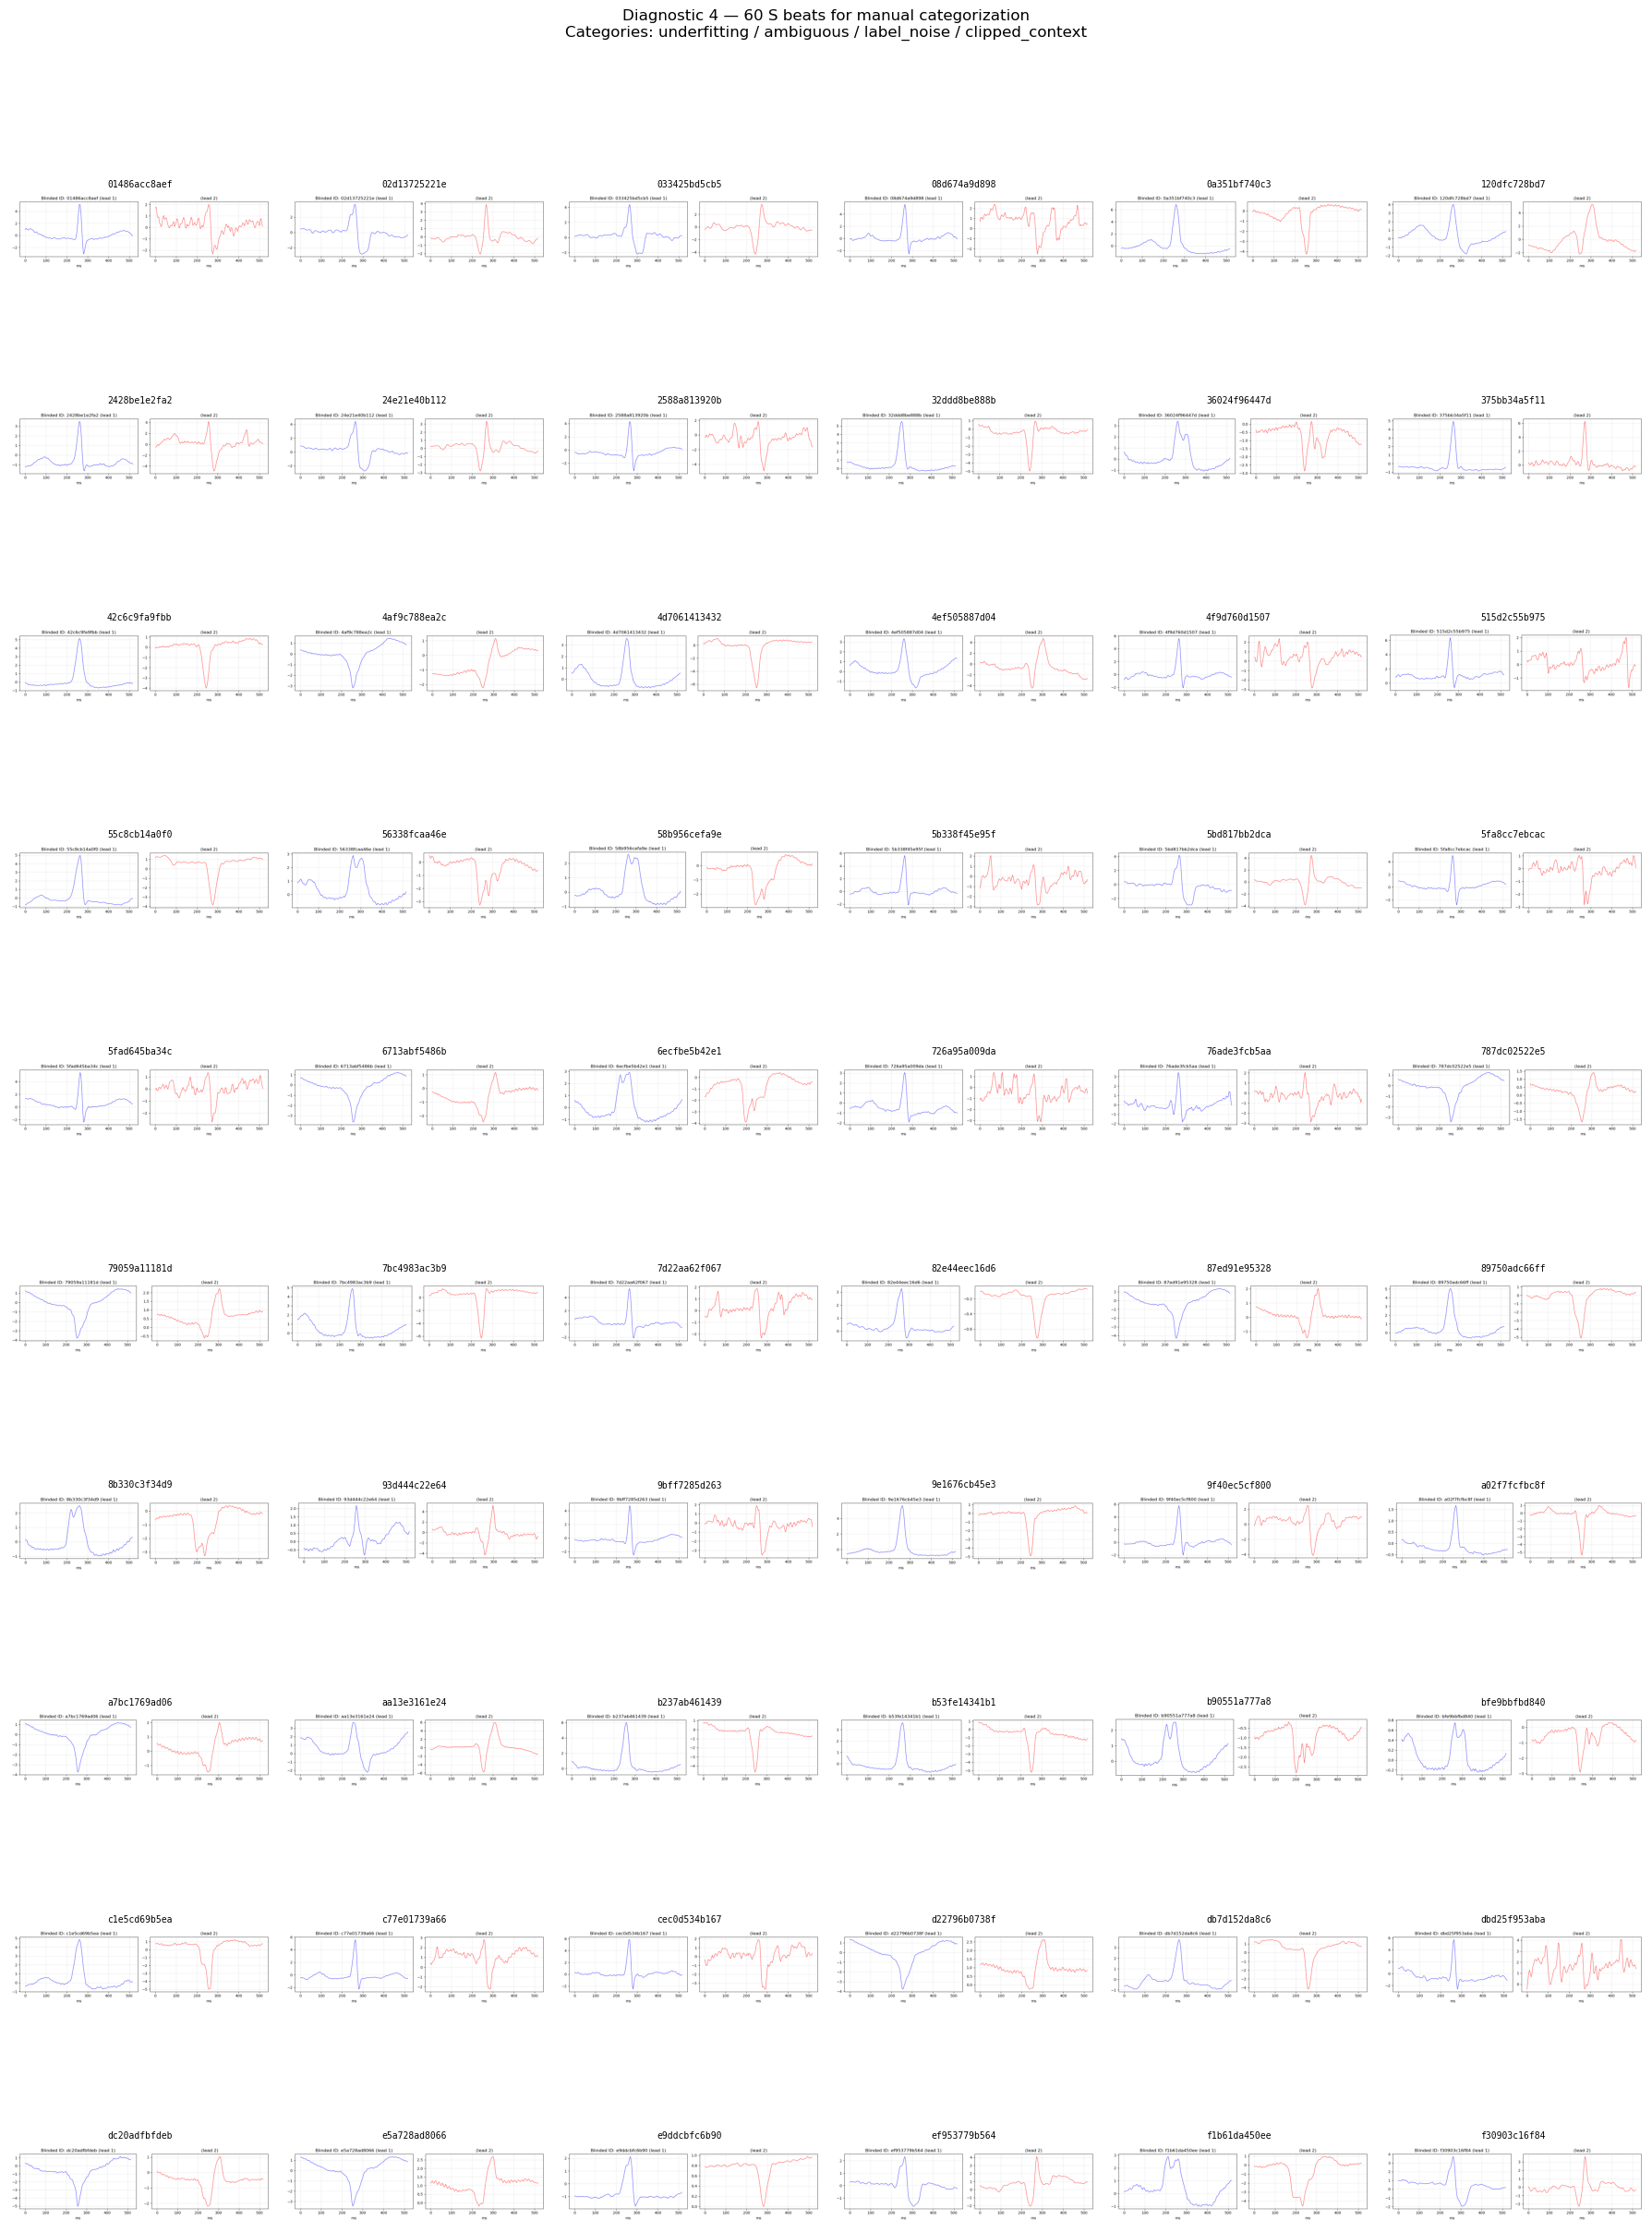

Saved: outputs_v91/contact_sheet_60.png
Open this file, categorize each beat, fill in:
  outputs_v9/inspection/blinded_for_categorization.csv


In [11]:
import hashlib
from matplotlib.image import imread

# ── Contact sheet for the 60 v9 inspection beats ─────────────────────────────
inspection_dir = f'{OUTPUTS_V9}/inspection/beats'
if os.path.isdir(inspection_dir):
    beat_files = sorted(glob.glob(f'{inspection_dir}/*.png'))
    print(f"Found {len(beat_files)} beat PNGs in {inspection_dir}")

    # Grid: 6 columns × 10 rows = 60 beats
    n_cols = 6; n_rows = (len(beat_files) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*2.5))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i, f in enumerate(beat_files):
        if i >= len(axes): break
        img = imread(f)
        axes[i].imshow(img)
        axes[i].axis('off')
        blinded_id = Path(f).stem
        axes[i].set_title(blinded_id, fontsize=7, fontfamily='monospace')

    # Hide unused axes
    for i in range(len(beat_files), len(axes)):
        axes[i].axis('off')

    plt.suptitle('Diagnostic 4 — 60 S beats for manual categorization\n'
                  'Categories: underfitting / ambiguous / label_noise / clipped_context',
                  fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_V91}/contact_sheet_60.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUTS_V91}/contact_sheet_60.png")
    print(f"Open this file, categorize each beat, fill in:")
    print(f"  {OUTPUTS_V9}/inspection/blinded_for_categorization.csv")
else:
    print(f"Inspection directory not found: {inspection_dir}")
    print("Run v9's Diagnostic 4 cell first to generate the beat PNGs.")


In [12]:
# ── Per-patient S beat dumps for the 6 zero-recovery patients ────────────────
# These patients had ZERO correctly classified S beats in v9. If many of their
# S beats are mislabeled, the S problem is partly an annotation problem.

zero_recovery_patients = ['mitbih_207', 'mitbih_118', 'mitbih_223',
                           'mitbih_203', 'mitbih_228', 'mitbih_231']

# Use v9's test set predictions to find S beats
gate_probs_test = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass = gate_probs_test > V9_GATE_THR
v_prob_test, s_prob_test = sv_model_v9.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0)
v_prob_test = v_prob_test.flatten(); s_prob_test = s_prob_test.flatten()
y_pred_v9 = np.full(len(y_test), n_idx, dtype=int)
if gate_pass.any():
    routed = np.full(gate_pass.sum(), n_idx, dtype=int)
    v_fire = v_prob_test[gate_pass] > V9_V_THR
    routed[v_fire] = v_idx
    s_fire = (~v_fire) & (s_prob_test[gate_pass] > V9_S_THR)
    routed[s_fire] = s_idx
    y_pred_v9[gate_pass] = routed

os.makedirs(f'{OUTPUTS_V91}/zero_recovery_patients', exist_ok=True)

for pat in zero_recovery_patients:
    pat_mask = (recs_test == pat) & (y_test == s_idx)
    n_pat = int(pat_mask.sum())
    if n_pat == 0:
        print(f"  {pat}: no S beats in test set")
        continue

    # Show up to 20 S beats from this patient
    idxs = np.where(pat_mask)[0]
    if len(idxs) > 20:
        idxs = np.random.default_rng(SEED).choice(idxs, 20, replace=False)

    n_show = len(idxs)
    n_cols = 5; n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*2.5))
    if n_rows == 1: axes = axes.reshape(1, -1) if n_cols > 1 else [axes]
    axes = axes.flatten()

    t_ms = np.arange(WINDOW_LEN) / TARGET_FS * 1000
    for i, idx in enumerate(idxs):
        if i >= len(axes): break
        beat = X_test[idx]
        axes[i].plot(t_ms, beat[:, 0], 'b-', linewidth=0.8)
        axes[i].plot(t_ms, beat[:, 1], 'r-', linewidth=0.8, alpha=0.5)
        pred = le.classes_[y_pred_v9[idx]]
        gate_p = gate_probs_test[idx]
        s_p = s_prob_test[idx]
        v_p = v_prob_test[idx]
        axes[i].set_title(f'idx={idx}\npred={pred} gate={gate_p:.2f} s={s_p:.2f} v={v_p:.2f}',
                           fontsize=6, fontfamily='monospace')
        axes[i].grid(alpha=0.3); axes[i].set_xticks([]); axes[i].set_yticks([])

    for i in range(n_show, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f'{pat} — {n_pat} true S beats (showing {n_show}), all misclassified\n'
                  f'Blue=lead1, Red=lead2. Check: is this really S? Is the P-wave visible? Is context clipped?',
                  fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_V91}/zero_recovery_patients/{pat}.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  {pat}: {n_pat} S beats → {OUTPUTS_V91}/zero_recovery_patients/{pat}.png")

print(f"\nOpen the PNGs in {OUTPUTS_V91}/zero_recovery_patients/")
print("For each beat, ask:")
print("  1. Does this look like an S beat (supraventricular ectopic)?")
print("     - Atrial premature beat: P-wave present but premature, QRS narrow")
print("     - If no P-wave and QRS is wide → it's V (ventricular), not S → label noise")
print("  2. Is the P-wave visible in the window? If clipped → clipped_context")
print("  3. Is the beat clearly premature (RR interval shorter than baseline)?")
print("  4. Could this be a normal beat that was annotated S by mistake?")

# Also dump the RR features for these patients' S beats
print("\nRR features for zero-recovery patients' S beats:")
print(f"{'Patient':<14} {'n_S':>4} {'rr_prev_mean':>12} {'rr_next_mean':>13} {'premat_idx':>11} {'comp_ratio':>11}")
for pat in zero_recovery_patients:
    pat_mask = (recs_test == pat) & (y_test == s_idx)
    if pat_mask.sum() == 0: continue
    rr = X_rr_test[pat_mask]
    print(f"{pat:<14} {pat_mask.sum():>4} {rr[:,0].mean():>12.4f} {rr[:,1].mean():>13.4f} "
          f"{rr[:,6].mean():>11.3f} {rr[:,5].mean():>11.3f}")

# Compare to correctly-classified S patients for reference
print(f"\n{'Correctly clsfd S patients (for comparison):':<14}")
for pat in ['mitbih_209', 'mitbih_202', 'mitbih_234']:
    pat_mask = (recs_test == pat) & (y_test == s_idx)
    if pat_mask.sum() == 0: continue
    rr = X_rr_test[pat_mask]
    print(f"{pat:<14} {pat_mask.sum():>4} {rr[:,0].mean():>12.4f} {rr[:,1].mean():>13.4f} "
          f"{rr[:,6].mean():>11.3f} {rr[:,5].mean():>11.3f}")


  mitbih_207: 107 S beats → outputs_v91/zero_recovery_patients/mitbih_207.png
  mitbih_118: 96 S beats → outputs_v91/zero_recovery_patients/mitbih_118.png
  mitbih_223: 73 S beats → outputs_v91/zero_recovery_patients/mitbih_223.png
  mitbih_203: 2 S beats → outputs_v91/zero_recovery_patients/mitbih_203.png
  mitbih_228: 3 S beats → outputs_v91/zero_recovery_patients/mitbih_228.png
  mitbih_231: 1 S beats → outputs_v91/zero_recovery_patients/mitbih_231.png

Open the PNGs in outputs_v91/zero_recovery_patients/
For each beat, ask:
  1. Does this look like an S beat (supraventricular ectopic)?
     - Atrial premature beat: P-wave present but premature, QRS narrow
     - If no P-wave and QRS is wide → it's V (ventricular), not S → label noise
  2. Is the P-wave visible in the window? If clipped → clipped_context
  3. Is the beat clearly premature (RR interval shorter than baseline)?
  4. Could this be a normal beat that was annotated S by mistake?

RR features for zero-recovery patients' S 

## Overnight run complete — what to look at in the morning

### Phase A verdict (first thing to check)
- If S F1 (RR-zeroed) > S F1 (v9 baseline) + 0.03 on test → **RR is the S blocker**. Read Phases B1 and B4 results next.
- If not → val finding was noise. Skip to Phase C1 (window 200) and Phase B3 (gate capacity).

### Phase B1 vs Phase A
- B1 (removed) vs A (zeroed): if B1 > A, the branch's architectural presence was part of the problem. If B1 ≈ A, the RR features themselves were the issue.

### Phase B2 (decoupled N mining)
- If B2 > v9 baseline: N-starvation was limiting the SV head. The fix is to decouple train/infer gate thresholds.
- Check the actual N share printed during training — was it > 0.10? (v9 was 0.019)

### Phase B4 (combined)
- If B4 > B1 and B4 > B2: the gains stack. This is your v9.1 final config.
- If B4 ≈ max(B1, B2): the gains don't stack — pick whichever individual change helped more.

### Phase B3 (gate 2×)
- Check the gate S-recall comparison table. If 2× gate S-recall > 1× gate S-recall at the same threshold by > 0.05, capacity was the gate's problem.
- If not, the gate's S-miss is an input/feature problem (window size, lead configuration, or annotation issues).

### Phase C1 (window 200)
- Compare S F1 @ 200 vs S F1 @ 130. If > +0.03, the KB was right — window size is the bottleneck.
- Check gate S-recall @ 200 vs @ 130 — does the longer window help the gate catch more S?

### Phase E (contact sheets)
- Open `contact_sheet_60.png` — categorize the 60 beats
- Open `zero_recovery_patients/*.png` — check if the 6 zero-recovery patients have annotation issues
- Fill in `outputs_v9/inspection/blinded_for_categorization.csv` and re-run v9 cell 30

### Files produced
- Models: `outputs_v91/sv_no_rr.keras`, `sv_decoupled.keras`, `gate_2x.keras`, `sv_combined.keras`, `gate_200.keras`, `sv_200.keras`
- Metrics: `outputs_v91/metrics/metrics_*.json`
- Summary: `outputs_v91/summary_comparison.csv`
- Contact sheets: `outputs_v91/contact_sheet_60.png`, `outputs_v91/zero_recovery_patients/*.png`
